# Transformer-BiLSTM + Fuzzy Pipeline for Credit Rating Prediction

Notebook sử dụng **Transformer-BiLSTM kết hợp Fuzzy Logic bảng PyTorch** để dự báo credit rating.

**Cách tiếp cận:**
- Bài toán được mô hình hóa dưới dạng **time-series classification**.
- Mỗi công ty (ticker) là một chuỗi thời gian riêng biệt.
- 12 đặc trưng tài chính là **input channels**.
- FuzzyLayer mở rộng đặc trưng theo membership functions (Low/Medium).
- Transformer dùng **relative positional bias** để học quan hệ theo thời gian.
- Target `y` là rating đã mã hóa số, tối ưu bảng **Focal + Ordinal Loss**.

**Kaggle Ready** | **Mixed Precision** | **Metric Curves đầy đủ**: Loss, Accuracy, F1, AUC, MAE, LR


## Table of Contents

1. Environment & Paths (Cell 2)
2. Imports, Seed, Device Setup (Cell 3)
3. Load Dataset (Cell 4)
4. Exploratory Data Analysis (Cell 5)
5. Windowing & DataLoader (Cell 6)
6. Model Definition (Cell 7)
7. Training Loop (Cell 8)
8. Evaluation (Cell 9)
9. Visualization (Cell 10)
10. SHAP Interpretation (Cell 11)
11. Summary


## 1. Environment and Dependency Setup

Khối này thiết lập môi trường chạy (Kaggle/local), import thư viện, random seed  và  cấu hình thiết bị.


In [1]:
import platform
import sys
from pathlib import Path

IN_KAGGLE = Path('/kaggle').exists()

def find_project_root(start: Path) -> Path:
    """Find repository root containing data/ and src/ when running locally."""
    for p in [start, *start.parents]:
        if (p / 'data').exists() and (p / 'src').exists():
            return p
    return start

CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = Path('/kaggle/working') if IN_KAGGLE else find_project_root(CURRENT_DIR)
WORKING_DIR = PROJECT_ROOT
ARTIFACT_DIR = WORKING_DIR / 'credit_rating_artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Python:', platform.python_version())
print('Running on Kaggle:', IN_KAGGLE)
print('Current directory:', CURRENT_DIR)
print('Project root:', PROJECT_ROOT)
print('Artifact directory:', ARTIFACT_DIR.resolve())

Python: 3.12.12
Running on Kaggle: True
Current directory: /kaggle/working
Project root: /kaggle/working
Artifact directory: /kaggle/working/credit_rating_artifacts


In [2]:
import random
import math
import warnings
import os
from contextlib import contextmanager
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, fbeta_score, roc_auc_score,
    precision_score, recall_score, roc_curve, auc,
    confusion_matrix, classification_report
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder, label_binarize, RobustScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def probe_cuda_runtime_for_lstm():
    """Check whether CUDA kernels required by LSTM are actually runnable."""
    if not torch.cuda.is_available():
        return False, 'torch.cuda.is_available() == False'

    try:
        # Trigger CUDA context + basic matmul kernel.
        probe_a = torch.randn(2, 2, device='cuda')
        probe_b = torch.randn(2, 2, device='cuda')
        _ = probe_a @ probe_b

        # Trigger cuDNN/cuBLAS path used by nn.LSTM.
        probe_lstm = nn.LSTM(input_size=4, hidden_size=4, batch_first=True).to('cuda')
        probe_x = torch.randn(2, 3, 4, device='cuda')
        with torch.no_grad():
            _ = probe_lstm(probe_x)

        torch.cuda.synchronize()
        del probe_a, probe_b, probe_lstm, probe_x
        return True, 'CUDA runtime probe passed'
    except Exception as e:
        return False, f'{type(e).__name__}: {e}'

CUDA_RUNTIME_OK, CUDA_RUNTIME_NOTE = probe_cuda_runtime_for_lstm()
if not CUDA_RUNTIME_OK and torch.cuda.is_available():
    warnings.warn(
        'CUDA is visible but not compatible with current PyTorch/CUDA kernels. '
        f'Falling back to CPU. Details: {CUDA_RUNTIME_NOTE}'
    )

device = torch.device('cuda' if CUDA_RUNTIME_OK else 'cpu')
USE_CUDA = device.type == 'cuda'
if USE_CUDA:
    torch.cuda.manual_seed_all(SEED)

# Training reproducibility knobs for more stable runs across executions.
DETERMINISTIC_TRAINING = True
if USE_CUDA:
    if DETERMINISTIC_TRAINING:
        os.environ['PYTHONHASHSEED'] = str(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

print('Using device:', device)
print('Deterministic training:', DETERMINISTIC_TRAINING)
print('CUDA runtime probe:', CUDA_RUNTIME_NOTE)

Using device: cpu
Deterministic training: True
CUDA runtime probe: AcceleratorError: CUDA error: no kernel image is available for execution on the device
Search for `cudaErrorNoKernelImageForDevice' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.



## 2. Data Loading and Basic Inspection

Tải dữ liệu nguồn, kiểm tra cấu trúc bảng  và  xác nhận schema đầu vào trước khi huấn luyện.


In [3]:
def resolve_split_path(default_path, local_fallbacks=None):
    """Resolve Kaggle path first, then local paths relative to PROJECT_ROOT."""
    candidates = [Path(default_path)]
    if local_fallbacks:
        for p in local_fallbacks:
            p_obj = Path(p)
            if p_obj.is_absolute():
                candidates.append(p_obj)
            else:
                candidates.append(PROJECT_ROOT / p_obj)
                candidates.append(p_obj)

    seen = set()
    ordered_candidates = []
    for c in candidates:
        c_norm = str(c.resolve()) if c.exists() else str(c)
        if c_norm not in seen:
            seen.add(c_norm)
            ordered_candidates.append(c)

    for p in ordered_candidates:
        if p.exists():
            return p
    raise FileNotFoundError(
        f'Cannot find data file. Tried: {[str(c) for c in ordered_candidates]}'
    )

TRAIN_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv',
    local_fallbacks=[
        'data/processed/train_augmented_timegan.csv',
        'archive/ctgan/splits/train_augmented_timegan.csv',
        'archive/ctgan/splits/train_augmented_ctgan.csv',
    ]
)
VAL_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/val.csv',
    local_fallbacks=[
        'data/processed/val.csv',
        'archive/ctgan/splits/val.csv',
        'data/processed/ctgan/splits/val.csv',
    ]
)
TEST_PATH = resolve_split_path(
    '/kaggle/input/datasets/tailength/corporate-credit-rating/test.csv',
    local_fallbacks=[
        'data/processed/test.csv',
        'archive/ctgan/splits/test.csv',
        'data/processed/ctgan/splits/test.csv',
    ]
)

ENFORCE_TICKER_DISJOINT = True

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

def ticker_set(frame):
    return set(frame['ticker'].astype(str).unique())

train_tickers_raw = ticker_set(train_df)
val_tickers_raw = ticker_set(val_df)
test_tickers_raw = ticker_set(test_df)

print('Ticker overlaps before optional disjoint filter:')
print(f"trainÄ‚Â¢Ă‹â€ Ă‚Â©val:  {len(train_tickers_raw & val_tickers_raw)}")
print(f"trainÄ‚Â¢Ă‹â€ Ă‚Â©test: {len(train_tickers_raw & test_tickers_raw)}")
print(f"valÄ‚Â¢Ă‹â€ Ă‚Â©test:   {len(val_tickers_raw & test_tickers_raw)}")

if ENFORCE_TICKER_DISJOINT:
    val_before = len(val_df)
    test_before = len(test_df)

    val_df = val_df[~val_df['ticker'].astype(str).isin(train_tickers_raw)].copy()
    val_tickers_after = ticker_set(val_df)
    blocked_for_test = train_tickers_raw | val_tickers_after
    test_df = test_df[~test_df['ticker'].astype(str).isin(blocked_for_test)].copy()

    print('\nDisjoint ticker filtering enabled:')
    print(f'Removed from val:  {val_before - len(val_df)} rows')
    print(f'Removed from test: {test_before - len(test_df)} rows')

    if len(val_df) == 0 or len(test_df) == 0:
        raise ValueError(
            'ENFORCE_TICKER_DISJOINT removed all rows from val/test. '
            'Please regenerate split files with ticker-disjoint partitioning.'
        )

train_df['__split__'] = 'train'
val_df['__split__'] = 'val'
test_df['__split__'] = 'test'

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print('Train path:', TRAIN_PATH)
print('Val path:  ', VAL_PATH)
print('Test path: ', TEST_PATH)
print('Train shape:', train_df.shape)
print('Val shape:  ', val_df.shape)
print('Test shape: ', test_df.shape)
print('Combined shape:', df.shape)
display(df.head())
df.info()

Ticker overlaps before optional disjoint filter:
trainÄ‚Â¢Ă‹â€ Ă‚Â©val:  575
trainÄ‚Â¢Ă‹â€ Ă‚Â©test: 493
valÄ‚Â¢Ă‹â€ Ă‚Â©test:   470

Disjoint ticker filtering enabled:
Removed from val:  2125 rows
Removed from test: 1081 rows
Train path: /kaggle/input/datasets/tailength/corporate-credit-rating/train_augmented_timegan.csv
Val path:   /kaggle/input/datasets/tailength/corporate-credit-rating/val.csv
Test path:  /kaggle/input/datasets/tailength/corporate-credit-rating/test.csv
Train shape: (8137, 21)
Val shape:   (125, 20)
Test shape:  (99, 20)
Combined shape: (8361, 21)


,rating_detail,company_name,ticker,rating_agency,rating_date,sector,source,current_ratio,debt_equity_ratio,gross_profit_margin,...,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,roe,roa,operating_cashflow_ps,free_cashflow_ps,is_synthetic,__split__
0,2,WPP CP LLC,WPP,5,2014-05-09,8,2,-0.808010,-0.189950,1.928982,...,0.003982,0.126718,0.099491,-0.677874,0.015935,-0.155452,0.953271,0.575491,0.0,train
1,2,O'Reilly Automotive Inc,ORLY,5,2012-08-16,4,2,0.214238,-0.663283,0.206979,...,0.035678,0.204221,0.033678,0.553252,0.020209,0.574236,1.035576,0.914196,0.0,train
2,0,__SYNTHETIC__,SYN_0_0000061,2,2013-12-15,5,2,0.293830,-1.138282,0.022112,...,-0.154876,-0.460833,-0.937023,-0.057865,0.396825,-0.093366,0.074455,1.155272,1.0,train
3,2,"ROCKWELL AUTOMATION, INC",ROK,1,2013-09-12,1,2,0.528577,-0.185749,-0.124587,...,0.279729,0.404467,0.389899,0.620284,0.703590,1.357475,0.129707,0.015366,0.0,train
4,2,FirstEnergy Corp.,FE,5,2012-06-15,9,1,-1.277904,0.938231,1.700440,...,-0.307270,-0.097883,-0.179376,-0.915296,-0.143425,-0.540010,1.842690,0.495642,0.0,train


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8361 entries, 0 to 8360
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   rating_detail            8361 non-null   int64  
 1   company_name             8361 non-null   object 
 2   ticker                   8361 non-null   object 
 3   rating_agency            8361 non-null   int64  
 4   rating_date              8361 non-null   object 
 5   sector                   8361 non-null   int64  
 6   source                   8361 non-null   int64  
 7   current_ratio            8361 non-null   float64
 8   debt_equity_ratio        8361 non-null   float64
 9   gross_profit_margin      8361 non-null   float64
 10  operating_profit_margin  8361 non-null   float64
 11  ebit_margin              8361 non-null   float64
 12  pretax_profit_margin     8361 non-null   float64
 13  net_profit_margin        8361 non-null   float64
 14  asset_turnover          

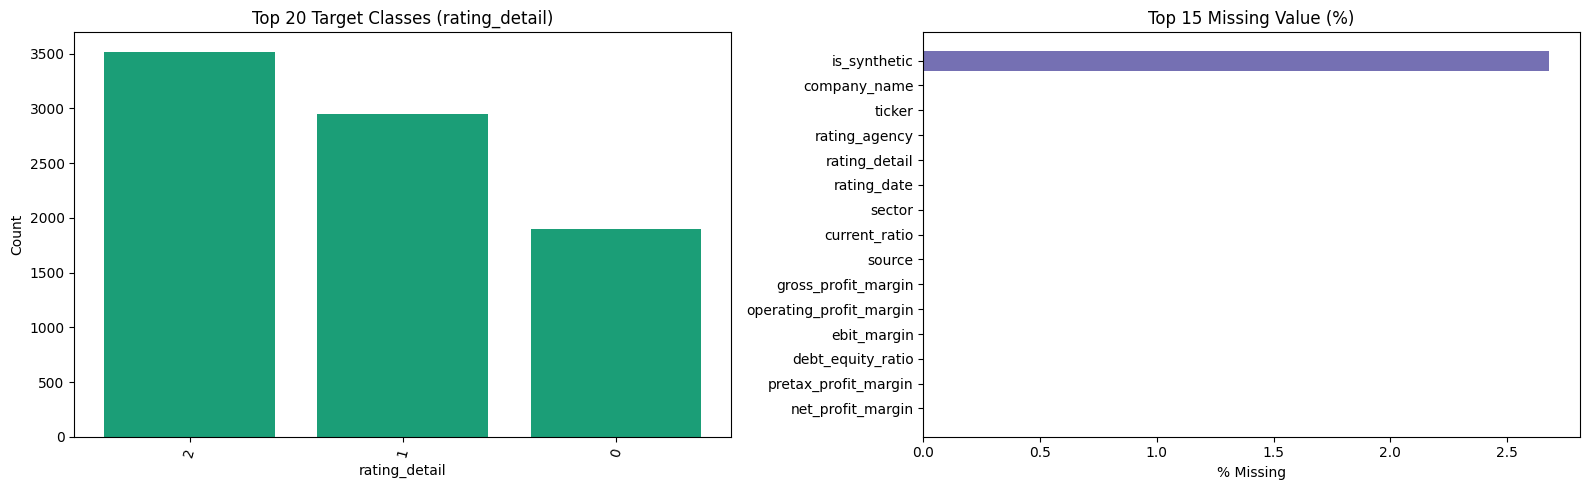

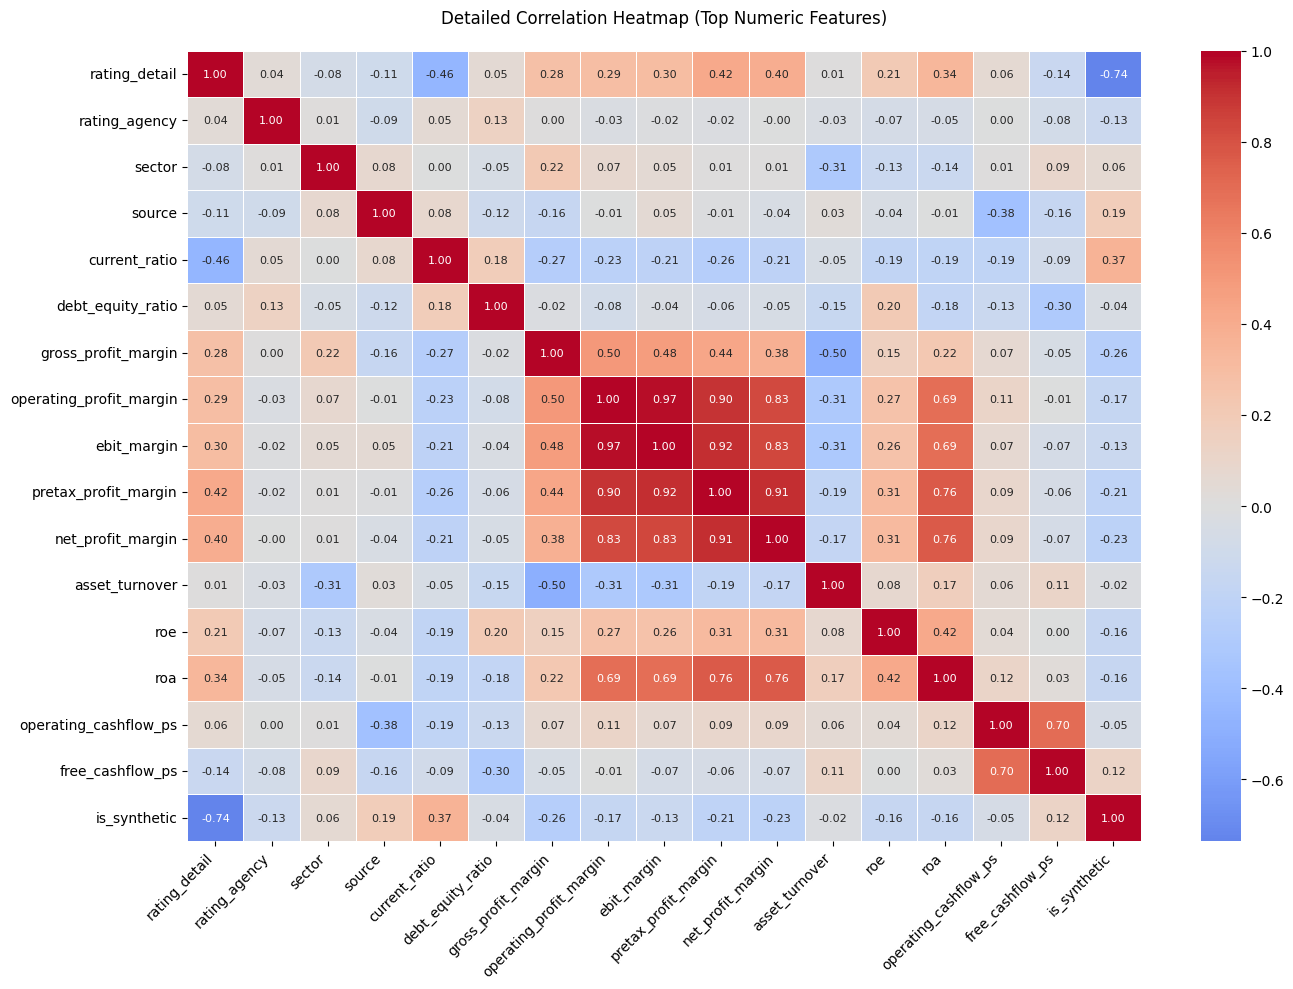

EDA plots (bars and heatmap) saved successfully.


In [4]:
# 1. VÄ‚Â¡Ă‚ÂºĂ‚Â½ 2 biÄ‚Â¡Ă‚Â»Ă†â€™u Ä‚â€Ă¢â‚¬ËœÄ‚Â¡Ă‚Â»Ă¢â‚¬Å“ biÄ‚Â¡Ă‚Â»Ă†â€™u diÄ‚Â¡Ă‚Â»Ă¢â‚¬Â¦n Bar charts (1 hĂ„â€Ă‚Â ng, 2 cÄ‚Â¡Ă‚Â»Ă¢â€Â¢t)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Ä‚â€Ă‚ÂÄ‚Â¡Ă‚Â»Ă¢â‚¬Å“ thÄ‚Â¡Ă‚Â»Ă¢â‚¬Â¹ 1: Top 20 Target Classes
target_counts = df['rating_detail'].value_counts().sort_values(ascending=False)
axes[0].bar(target_counts.index.astype(str), target_counts.values, color='#1b9e77')
axes[0].set_title('Top 20 Target Classes (rating_detail)')
axes[0].set_xlabel('rating_detail')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=75)

# Ä‚â€Ă‚ÂÄ‚Â¡Ă‚Â»Ă¢â‚¬Å“ thÄ‚Â¡Ă‚Â»Ă¢â‚¬Â¹ 2: Top 15 Missing Value (%)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
top_missing = missing_pct.head(15)
axes[1].barh(top_missing.index[::-1], top_missing.values[::-1], color='#7570b3')
axes[1].set_title('Top 15 Missing Value (%)')
axes[1].set_xlabel('% Missing')

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'eda_bars.png', dpi=150, bbox_inches='tight')
plt.show()

# -----------------------------------------------------------------------------
# 2. TĂ„â€Ă‚Â¡ch riĂ„â€Ă‚Âªng biÄ‚Â¡Ă‚Â»Ă†â€™u Ä‚â€Ă¢â‚¬ËœÄ‚Â¡Ă‚Â»Ă¢â‚¬Å“ Correlation Heatmap
# LÄ‚Â¡Ă‚Â»Ă‚Â±a chÄ‚Â¡Ă‚Â»Ă‚Ân 20 features sÄ‚Â¡Ă‚Â»Ă¢â‚¬Ëœ thÄ‚Â¡Ă‚Â»Ă‚Â±c (loÄ‚Â¡Ă‚ÂºĂ‚Â¡i bÄ‚Â¡Ă‚Â»Ă‚Â binary_rating) Ä‚â€Ă¢â‚¬ËœÄ‚Â¡Ă‚Â»Ă†â€™ quan sĂ„â€Ă‚Â¡t chi tiÄ‚Â¡Ă‚ÂºĂ‚Â¿t nhÄ‚Â¡Ă‚ÂºĂ‚Â¥t vĂ„â€Ă‚Â²ng TÄ‚â€ Ă‚Â°Ä‚â€ Ă‚Â¡ng quan
num_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols_corr = [c for c in num_cols_all if c not in ['binary_rating']][:20] 
corr = df[num_cols_corr].corr()

plt.figure(figsize=(14, 10)) # Ä‚â€Ă‚ÂÄ‚Â¡Ă‚Â»Ă¢â‚¬Â¹nh cÄ‚Â¡Ă‚ÂºĂ‚Â¥u hĂ„â€Ă‚Â¬nh Ä‚Â¡Ă‚ÂºĂ‚Â£nh to, dÄ‚Â¡Ă‚Â»Ă¢â‚¬Â¦ review
sns.heatmap(
    corr, 
    cmap='coolwarm', 
    center=0, 
    annot=True,         # BÄ‚Â¡Ă‚ÂºĂ‚Â­t chi tiÄ‚Â¡Ă‚ÂºĂ‚Â¿t sÄ‚Â¡Ă‚Â»Ă¢â‚¬Ëœ liÄ‚Â¡Ă‚Â»Ă¢â‚¬Â¡u correlation trĂ„â€Ă‚Âªn tÄ‚Â¡Ă‚Â»Ă‚Â«ng Ă„â€Ă‚Â´
    fmt=".2f",          # LĂ„â€Ă‚Â m trĂ„â€Ă‚Â²n 2 chÄ‚Â¡Ă‚Â»Ă‚Â¯ sÄ‚Â¡Ă‚Â»Ă¢â‚¬Ëœ thÄ‚Â¡Ă‚ÂºĂ‚Â­p phĂ„â€Ă‚Â¢n
    linewidths=0.5,     # TÄ‚Â¡Ă‚ÂºĂ‚Â¡o Ä‚â€Ă¢â‚¬ËœÄ‚â€ Ă‚Â°Ä‚Â¡Ă‚Â»Ă‚Âng lÄ‚â€ Ă‚Â°Ä‚Â¡Ă‚Â»Ă¢â‚¬Âºi mÄ‚Â¡Ă‚Â»Ă‚Âng nĂ„â€Ă‚Â©t cho cĂ„â€Ă‚Â¡c Ă„â€Ă‚Â´
    annot_kws={"size": 8} # Thu nhÄ‚Â¡Ă‚Â»Ă‚Â font size sÄ‚Â¡Ă‚Â»Ă¢â‚¬Ëœ Ä‚â€Ă¢â‚¬ËœÄ‚Â¡Ă‚Â»Ă†â€™ trĂ„â€Ă‚Â¡nh bÄ‚Â¡Ă‚Â»Ă¢â‚¬Â¹ Ä‚â€Ă¢â‚¬ËœĂ„â€Ă‚Â¨ nÄ‚Â¡Ă‚ÂºĂ‚Â¿u chÄ‚Â¡Ă‚Â»Ă‚Â¯ quĂ„â€Ă‚Â¡ dĂ„â€Ă‚Â i
)
plt.title('Detailed Correlation Heatmap (Top Numeric Features)', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(ARTIFACT_DIR / 'eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('EDA plots (bars and heatmap) saved successfully.')


## 3. Target Validation and Feature Preprocessing

Xác thực biến mục tiêu, chuẩn hóa cột đặc trưng  và  chuẩn bị dữ liệu nhất quán giữa train/val/test.


In [5]:
FINANCIAL_FEATURES = [
    'current_ratio', 'debt_equity_ratio',
    'gross_profit_margin', 'operating_profit_margin',
    'ebit_margin', 'pretax_profit_margin',
    'net_profit_margin', 'asset_turnover',
    'roe', 'roa',
    'operating_cashflow_ps', 'free_cashflow_ps'

 ]

SECTOR_COL = 'sector'
SECTOR_UNKNOWN = 'UNKNOWN'
TARGET_COL = 'rating_detail'

# If labels are strings, keep this risk order when available.
TARGET_ORDERED_LABELS = ['Distressed', 'HY', 'IG']

before_rows = len(df)
df = df.dropna(subset=[TARGET_COL]).copy()

target_as_num = pd.to_numeric(df[TARGET_COL], errors='coerce')
if target_as_num.notna().all():
    # Numeric labels path (e.g., 0/1/2). Remap to contiguous IDs from observed classes.
    df[TARGET_COL] = target_as_num.astype(int)
    observed_classes_raw = sorted(df[TARGET_COL].unique().tolist())
    raw_to_id = {int(raw): idx for idx, raw in enumerate(observed_classes_raw)}
    id_to_raw = {idx: int(raw) for raw, idx in raw_to_id.items()}
    df[TARGET_COL] = df[TARGET_COL].map(raw_to_id).astype(int)
else:
    # String labels path (e.g., Distressed/HY/IG).
    target_as_str = df[TARGET_COL].astype(str).str.strip()
    observed_str = sorted(target_as_str.unique().tolist())
    if set(observed_str).issubset(set(TARGET_ORDERED_LABELS)):
        ordered_present = [c for c in TARGET_ORDERED_LABELS if c in observed_str]
    else:
        ordered_present = observed_str
    raw_to_id = {raw: idx for idx, raw in enumerate(ordered_present)}
    id_to_raw = {idx: raw for raw, idx in raw_to_id.items()}
    df[TARGET_COL] = target_as_str.map(raw_to_id).astype(int)

EXPECTED_CLASSES = sorted(df[TARGET_COL].unique().tolist())
if EXPECTED_CLASSES != list(range(len(EXPECTED_CLASSES))):
    raise ValueError(f'Label IDs must be contiguous from 0. Got: {EXPECTED_CLASSES}')

n_classes = len(EXPECTED_CLASSES)
TARGET_MIN, TARGET_MAX = 0, n_classes - 1

# Keep encoder-like metadata object for downstream checkpoint compatibility.
class _StaticLabelEncoder:
    def __init__(self, classes):
        self.classes_ = np.array(classes, dtype=object)

le = _StaticLabelEncoder(classes=[id_to_raw[i] for i in range(n_classes)])

df['rating_date'] = pd.to_datetime(df['rating_date'], format='mixed')

if SECTOR_COL not in df.columns:
    df[SECTOR_COL] = SECTOR_UNKNOWN
df[SECTOR_COL] = df[SECTOR_COL].fillna(SECTOR_UNKNOWN).astype(str).str.strip()
df.loc[df[SECTOR_COL] == '', SECTOR_COL] = SECTOR_UNKNOWN

sector_encoder = LabelEncoder()
df['sector_id'] = sector_encoder.fit_transform(df[SECTOR_COL])
SECTOR_CLASSES = sector_encoder.classes_.tolist()
n_sectors = len(SECTOR_CLASSES)

# Leakage guard: estimate imputation/clipping statistics on train split only.
if '__split__' in df.columns:
    split_series = df['__split__'].astype(str).str.lower()
    train_mask_raw = split_series == 'train'
    has_train_rows = bool(train_mask_raw.any())
else:
    train_mask_raw = pd.Series(False, index=df.index)
    has_train_rows = False

stats_ref = df.loc[train_mask_raw].copy() if has_train_rows else df.copy()

for col in FINANCIAL_FEATURES:
    med = stats_ref[col].median() if stats_ref[col].notna().any() else df[col].median()
    if pd.isna(med):
        med = 0.0
    if df[col].isna().any():
        df[col] = df[col].fillna(float(med))

for col in FINANCIAL_FEATURES:
    lower = stats_ref[col].quantile(0.01)
    upper = stats_ref[col].quantile(0.99)
    if pd.isna(lower) or pd.isna(upper):
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
    if pd.isna(lower) or pd.isna(upper):
        continue
    df[col] = df[col].clip(float(lower), float(upper))

print(f'Rows kept after target cleanup: {len(df)} / {before_rows}')
print(f'Number of classes (observed): {n_classes}')
print(f'Label range (model IDs): {TARGET_MIN}..{TARGET_MAX}')
print('Observed label IDs:', sorted(df[TARGET_COL].unique().tolist()))
print('Raw-to-ID mapping:', raw_to_id)
print('Decoder classes (ID -> raw):', le.classes_.tolist())
print(f'Sectors encoded: {n_sectors}')
print(f"Leakage guard reference split: {'train' if has_train_rows else 'all_data_fallback'}")
print('Sample sectors:', SECTOR_CLASSES[:10])
print(f'\nData after preprocessing: {df.shape}')

Rows kept after target cleanup: 8361 / 8361
Number of classes (observed): 3
Label range (model IDs): 0..2
Observed label IDs: [0, 1, 2]
Raw-to-ID mapping: {0: 0, 1: 1, 2: 2}
Decoder classes (ID -> raw): [0, 1, 2]
Sectors encoded: 12
Leakage guard reference split: train
Sample sectors: ['0', '1', '10', '11', '2', '3', '4', '5', '6', '7']

Data after preprocessing: (8361, 22)


## 4. Panel Time-Series Construction

Chuyển dữ liệu về dạng panel theo ticker  và  timeline để tạo đầu vào chuỗi thời gian ổn định.


In [6]:
df_sorted = df.sort_values(['ticker', 'rating_date']).reset_index(drop=True)

panel_df = df_sorted[
    ['ticker', 'rating_date', 'rating_detail', 'sector_id', '__split__'] + FINANCIAL_FEATURES
].copy()
panel_df = panel_df.rename(columns={
    'ticker': 'unique_id',
    'rating_date': 'ds',
    'rating_detail': 'y'
})

ticker_counts = panel_df.groupby('unique_id').size().reset_index(name='count')
print('Ticker count statistics:')
print(ticker_counts['count'].describe())
print()

MIN_HISTORY = 1
valid_tickers = ticker_counts[ticker_counts['count'] >= MIN_HISTORY]['unique_id'].tolist()
panel_df = panel_df[panel_df['unique_id'].isin(valid_tickers)].reset_index(drop=True)

print(f'Tickers with >= {MIN_HISTORY} data points: {len(valid_tickers)}')
print(f'Panel DataFrame shape: {panel_df.shape}')
print(f'Unique tickers: {panel_df["unique_id"].nunique()}')
print(f'Date range: {panel_df["ds"].min()} to {panel_df["ds"].max()}')
print(f'Unique sectors (encoded): {panel_df["sector_id"].nunique()}')
print('Split distribution:')
print(panel_df['__split__'].value_counts())
display(panel_df.head(10))

Ticker count statistics:
count    1206.000000
mean        6.932836
std         4.965571
min         1.000000
25%         2.000000
50%         8.000000
75%         9.000000
max        28.000000
Name: count, dtype: float64

Tickers with >= 1 data points: 1206
Panel DataFrame shape: (8361, 17)
Unique tickers: 1206
Date range: 2005-08-16 00:00:00 to 2016-12-21 00:00:00
Unique sectors (encoded): 12
Split distribution:
__split__
train    8137
val       125
test       99
Name: count, dtype: int64


,unique_id,ds,y,sector_id,__split__,current_ratio,debt_equity_ratio,gross_profit_margin,operating_profit_margin,ebit_margin,pretax_profit_margin,net_profit_margin,asset_turnover,roe,roa,operating_cashflow_ps,free_cashflow_ps
0,AA,2015-10-14,1,0,val,-0.712008,-0.234253,-0.968518,-1.122860,-1.203761,-1.175088,-1.421682,-0.150691,-0.547394,-1.808632,1.435162,0.709194
1,AAL,2013-11-12,1,3,train,-0.753091,-4.091674,2.272752,-0.620838,-1.744159,-1.501790,-1.344491,-0.252807,1.402772,-1.648999,1.316342,-2.816574
2,AAP,2012-06-15,2,6,train,-0.737992,-0.260164,0.254470,-0.168600,-0.155478,0.010862,-0.093115,1.442557,0.876026,0.987221,1.091795,0.488210
3,AAP,2013-05-29,2,6,train,-0.481150,-0.251704,0.261951,-0.182775,-0.169620,-0.005112,-0.106478,0.978379,0.504705,0.590076,-1.251035,-0.615030
4,AAP,2013-09-25,2,6,train,-0.481150,-0.251704,0.261951,-0.182775,-0.169620,-0.005112,-0.106478,0.978379,0.504705,0.590076,-1.251035,-0.615030
5,AAP,2013-11-13,2,6,train,-0.481150,-0.251704,0.261951,-0.182775,-0.169620,-0.005112,-0.106478,0.978379,0.504705,0.590076,-1.251035,-0.615030
6,AAP,2013-11-25,2,6,train,-0.481150,-0.251704,0.261951,-0.182775,-0.169620,-0.005112,-0.106478,0.978379,0.504705,0.590076,-1.251035,-0.615030
7,AAP,2014-02-21,2,6,train,-0.241981,-0.083565,0.268084,-0.216705,-0.203471,-0.037296,-0.126230,0.710111,0.346678,0.360112,-1.373500,-0.315845
8,AAP,2014-06-18,2,6,train,-0.241981,-0.083565,0.268084,-0.216705,-0.203471,-0.037296,-0.126230,0.710111,0.346678,0.360112,-1.373500,-0.315845
9,AAP,2014-09-02,2,6,train,-0.241981,-0.083565,0.268084,-0.216705,-0.203471,-0.037296,-0.126230,0.710111,0.346678,0.360112,-1.373500,-0.315845


## 5. Sliding Windows, Split, and DataLoaders

Tạo mẫu cửa sổ thời gian, chia train/val/test theo nguyên tắc chống leakage  và  build DataLoader.


In [7]:
# Adaptive context length search to maximize usable windows while preserving enough temporal context.
HORIZON = 1
ALLOW_SHORT_TICKER_PADDING = True
WINDOW_PADDING_MODE = 'edge'   # 'edge' or 'zero'

INPUT_SIZE_SEARCH_ENABLED = False
INPUT_SIZE_DEFAULT = 1  # Audit Fix F2: was 1 Ă¢â‚¬â€ enables Transformer+BiLSTM temporal stack
INPUT_SIZE_MIN = 0
INPUT_SIZE_MAX = 24
SINGLETON_TICKER_POLICY = 'self_target_padded'
ENABLE_BOOTSTRAP_T0_WINDOW = True
ENABLE_SYNTH_QC = True
ENABLE_WEIGHTED_SAMPLER = True
SAMPLER_WEIGHT_POWER = 0.85  # Audit Fix F1: slightly stronger since class_weights removed


def estimate_window_counts(panel_frame, input_size, horizon=1, allow_short_padding=True):
    """Estimate split-wise window counts for a given input_size using current split labels."""
    counts = {'train': 0, 'val': 0, 'test': 0}
    padded_counts = {'train': 0, 'val': 0, 'test': 0}

    for _, grp in panel_frame.groupby('unique_id'):
        g = grp.sort_values('ds').reset_index(drop=True)
        n = len(g)

        if n < 1:
            continue
        if n < horizon + 1 and not allow_short_padding:
            continue

        if n >= input_size + horizon:
            max_i = n - input_size - horizon + 1
            for i in range(max_i):
                target_idx = i + input_size
                split_label = str(g['__split__'].iloc[target_idx]).lower()
                if split_label in counts:
                    counts[split_label] += 1
        elif allow_short_padding:
            # One padded sample from the latest available target when history is short.
            target_idx = n - 1
            split_label = str(g['__split__'].iloc[target_idx]).lower()
            if split_label in counts:
                counts[split_label] += 1
                padded_counts[split_label] += 1

    total = int(sum(counts.values()))
    total_padded = int(sum(padded_counts.values()))
    return counts, padded_counts, total, total_padded


# Candidate input sizes based on available ticker history.
max_ticker_len = int(ticker_counts['count'].max()) if len(ticker_counts) > 0 else (INPUT_SIZE_DEFAULT + HORIZON)
search_upper = max(INPUT_SIZE_MIN, min(INPUT_SIZE_MAX, max_ticker_len - HORIZON))
input_candidates = list(range(INPUT_SIZE_MIN, search_upper + 1)) if search_upper >= INPUT_SIZE_MIN else [INPUT_SIZE_DEFAULT]
if INPUT_SIZE_DEFAULT not in input_candidates:
    input_candidates.append(INPUT_SIZE_DEFAULT)
input_candidates = sorted(set([int(v) for v in input_candidates if int(v) >= 1]))

search_rows = []
for k in input_candidates:
    est_counts, est_padded, est_total, est_total_padded = estimate_window_counts(
        panel_df,
        input_size=int(k),
        horizon=HORIZON,
        allow_short_padding=ALLOW_SHORT_TICKER_PADDING,
    )
    search_rows.append({
        'input_size': int(k),
        'train_windows': int(est_counts['train']),
        'val_windows': int(est_counts['val']),
        'test_windows': int(est_counts['test']),
        'total_windows': int(est_total),
        'padded_windows_total': int(est_total_padded),
    })

search_df = pd.DataFrame(search_rows).sort_values('input_size').reset_index(drop=True)
if len(search_df) == 0:
    raise ValueError('No valid INPUT_SIZE candidate found for sliding-window construction.')

max_train = float(search_df['train_windows'].max()) if search_df['train_windows'].max() > 0 else 1.0
max_total = float(search_df['total_windows'].max()) if search_df['total_windows'].max() > 0 else 1.0
max_k = float(search_df['input_size'].max()) if search_df['input_size'].max() > 0 else 1.0

# Score balances: train coverage (70%), overall coverage (20%), context length (10%).
search_df['score'] = (
    0.70 * (search_df['train_windows'] / max_train) +
    0.20 * (search_df['total_windows'] / max_total) +
    0.10 * (search_df['input_size'] / max_k)
)

if INPUT_SIZE_SEARCH_ENABLED:
    feasible_df = search_df[
        (search_df['train_windows'] > 0) &
        (search_df['val_windows'] > 0) &
        (search_df['test_windows'] > 0)
    ].copy()

    if len(feasible_df) > 0:
        best_row = feasible_df.sort_values(['score', 'train_windows', 'input_size'], ascending=[False, False, False]).iloc[0]
        INPUT_SIZE = int(best_row['input_size'])
        input_size_reason = 'adaptive_search'
    else:
        INPUT_SIZE = int(np.clip(INPUT_SIZE_DEFAULT, 1, INPUT_SIZE_MAX))
        input_size_reason = 'fallback_default_no_feasible_candidate'
else:
    INPUT_SIZE = int(np.clip(INPUT_SIZE_DEFAULT, 1, INPUT_SIZE_MAX))
    input_size_reason = 'search_disabled'

INPUT_SIZE_SEARCH_REPORT = search_df.copy()

print(f'INPUT_SIZE selected: {INPUT_SIZE} ({input_size_reason})')
print(f'HORIZON (forecast): {HORIZON}')
print(f'Short ticker padding enabled: {ALLOW_SHORT_TICKER_PADDING} ({WINDOW_PADDING_MODE})')
print(f'Singleton ticker policy: {SINGLETON_TICKER_POLICY}')
print('\nTop input-size candidates by score:')
print(
    search_df
    .sort_values(['score', 'train_windows', 'input_size'], ascending=[False, False, False])
    .head(8)
    .to_string(index=False)
)

min_required = INPUT_SIZE + HORIZON
eligible_full_window_tickers = ticker_counts[ticker_counts['count'] >= min_required]['unique_id'].tolist()
panel_df_filtered = panel_df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

print(f'\nTickers with >= {min_required} data points (full windows): {len(eligible_full_window_tickers)}')
print(f'Panel shape (no hard drop by min_required): {panel_df_filtered.shape}')

# -- Feature engineering: add first-order deltas by ticker to capture trend changes --
DELTA_FEATURES = []
for col in FINANCIAL_FEATURES:
    dcol = f'{col}_delta'
    panel_df_filtered[dcol] = (
        panel_df_filtered.groupby('unique_id')[col].diff().fillna(0.0)
    )
    DELTA_FEATURES.append(dcol)

MODEL_FEATURES = FINANCIAL_FEATURES + DELTA_FEATURES

# -- Global scaling (fit on train split only), replacing RevIN normalization --
scaler = RobustScaler()
train_feature_mask = panel_df_filtered['__split__'] == 'train'
if train_feature_mask.any():
    scaler.fit(panel_df_filtered.loc[train_feature_mask, MODEL_FEATURES].values)
else:
    scaler.fit(panel_df_filtered[MODEL_FEATURES].values)
panel_df_filtered[MODEL_FEATURES] = scaler.transform(
    panel_df_filtered[MODEL_FEATURES].values
)

# -- Build sliding window dataset --
class CreditRatingDataset(Dataset):
    """Sliding window dataset.
    Returns X shape (INPUT_SIZE, n_channels), last_y context, and sector_id."""
    def __init__(self, sequences, augment=False, noise_std=0.0, feature_dropout_prob=0.0):
        self.sequences = sequences
        self.augment = augment
        self.noise_std = float(noise_std)
        self.feature_dropout_prob = float(feature_dropout_prob)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        X, last_y, sector_id, y_target = self.sequences[idx]
        X = np.asarray(X, dtype=np.float32).copy()

        if self.augment:
            if self.noise_std > 0:
                X += np.random.normal(0.0, self.noise_std, size=X.shape).astype(np.float32)
            if self.feature_dropout_prob > 0:
                drop_mask = np.random.rand(X.shape[1]) < self.feature_dropout_prob
                if drop_mask.any():
                    X[:, drop_mask] = 0.0

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(last_y, dtype=torch.long),
            torch.tensor(sector_id, dtype=torch.long),
            torch.tensor(y_target, dtype=torch.long),
        )


def build_padded_window(values, target_idx, input_size, mode='edge'):
    """Build fixed-length window ending right before target_idx with optional left padding."""
    if values.shape[0] == 0:
        return None

    # For singleton tickers, fallback to the first row as minimal context.
    if target_idx <= 0:
        X_raw = values[:1]
    else:
        start_idx = max(0, target_idx - input_size)
        X_raw = values[start_idx:target_idx]

    if X_raw.shape[0] == 0:
        X_raw = values[:1]

    if X_raw.shape[0] >= input_size:
        return X_raw[-input_size:]

    pad_len = input_size - X_raw.shape[0]
    if mode == 'zero':
        pad_block = np.zeros((pad_len, X_raw.shape[1]), dtype=X_raw.dtype)
    else:
        pad_block = np.repeat(X_raw[[0]], pad_len, axis=0)

    return np.concatenate([pad_block, X_raw], axis=0)


feature_cols = MODEL_FEATURES
n_channels = len(feature_cols)

train_seqs = []
val_seqs = []
test_seqs = []
test_seq_tickers = []
train_seq_is_synth = []
train_seq_is_change = []
has_synth_col = 'is_synthetic' in panel_df_filtered.columns

short_seq_windows_added = 0
singleton_windows_added = 0
bootstrap_t0_windows_added = 0
short_seq_tickers_used = set()

for uid, grp in panel_df_filtered.groupby('unique_id'):
    grp = grp.sort_values('ds').reset_index(drop=True)
    values = grp[feature_cols].values  # (T, C)
    n = len(values)

    if n == 0:
        continue

    if ENABLE_BOOTSTRAP_T0_WINDOW and n >= INPUT_SIZE + HORIZON:
        # Add one extra sample at the first timestamp to maximize train coverage.
        target_idx = 0
        X0 = build_padded_window(values, target_idx=target_idx, input_size=INPUT_SIZE, mode=WINDOW_PADDING_MODE)
        if X0 is not None and X0.shape[0] == INPUT_SIZE:
            last_y0 = int(grp['y'].iloc[target_idx])
            y_target0 = int(grp['y'].iloc[target_idx])
            sector_id0 = int(grp['sector_id'].iloc[target_idx])
            split_label0 = str(grp['__split__'].iloc[target_idx]).lower()

            sample0 = (X0, last_y0, sector_id0, y_target0)
            if split_label0 == 'test':
                test_seqs.append(sample0)
                test_seq_tickers.append(uid)
            elif split_label0 == 'val':
                val_seqs.append(sample0)
            else:
                train_seqs.append(sample0)
                train_seq_is_change.append(int(y_target0 != last_y0))
                if has_synth_col:
                    train_seq_is_synth.append(int(grp['is_synthetic'].iloc[target_idx]))
                else:
                    train_seq_is_synth.append(0)

            bootstrap_t0_windows_added += 1
    if n < HORIZON + 1 and not ALLOW_SHORT_TICKER_PADDING:
        continue

    if n < INPUT_SIZE + HORIZON and ALLOW_SHORT_TICKER_PADDING:
        # Keep short ticker (including n=1) by creating one padded window.
        target_idx = n - 1
        X = build_padded_window(values, target_idx=target_idx, input_size=INPUT_SIZE, mode=WINDOW_PADDING_MODE)
        if X is not None and X.shape[0] == INPUT_SIZE:
            last_y_idx = max(0, target_idx - 1)
            last_y = int(grp['y'].iloc[last_y_idx])
            y_target = int(grp['y'].iloc[target_idx])
            sector_id = int(grp['sector_id'].iloc[target_idx])
            split_label = str(grp['__split__'].iloc[target_idx]).lower()

            sample = (X, last_y, sector_id, y_target)
            if split_label == 'test':
                test_seqs.append(sample)
                test_seq_tickers.append(uid)
            elif split_label == 'val':
                val_seqs.append(sample)
            else:
                train_seqs.append(sample)
                train_seq_is_change.append(int(y_target != last_y))
                if has_synth_col:
                    train_seq_is_synth.append(int(grp['is_synthetic'].iloc[target_idx]))
                else:
                    train_seq_is_synth.append(0)

            short_seq_windows_added += 1
            if n == 1:
                singleton_windows_added += 1
            short_seq_tickers_used.add(uid)
        continue

    for i in range(n - INPUT_SIZE - HORIZON + 1):
        X = values[i : i + INPUT_SIZE]
        last_y = int(grp['y'].iloc[i + INPUT_SIZE - 1])
        target_idx = i + INPUT_SIZE
        y_target = int(grp['y'].iloc[target_idx])  # next-step class
        sector_id = int(grp['sector_id'].iloc[target_idx])
        split_label = str(grp['__split__'].iloc[target_idx]).lower()

        sample = (X, last_y, sector_id, y_target)
        if split_label == 'test':
            test_seqs.append(sample)
            test_seq_tickers.append(uid)
        elif split_label == 'val':
            val_seqs.append(sample)
        else:
            train_seqs.append(sample)
            train_seq_is_change.append(int(y_target != last_y))
            if has_synth_col:
                train_seq_is_synth.append(int(grp['is_synthetic'].iloc[target_idx]))
            else:
                train_seq_is_synth.append(0)

train_tickers = set(
    panel_df_filtered.loc[panel_df_filtered['__split__'] == 'train', 'unique_id'].tolist()
)
val_tickers = set(
    panel_df_filtered.loc[panel_df_filtered['__split__'] == 'val', 'unique_id'].tolist()
)

if len(train_seqs) == 0 or len(val_seqs) == 0 or len(test_seqs) == 0:
    raise ValueError(
        f'Empty split sequences found: train={len(train_seqs)}, val={len(val_seqs)}, test={len(test_seqs)}. '
        'Please check split files and time-order windows.'
    )

test_seq_tickers = np.array(test_seq_tickers, dtype=object)
train_seq_is_synth = np.array(train_seq_is_synth, dtype=int)
train_seq_is_change = np.array(train_seq_is_change, dtype=int)

# -- Synthetic sequence quality control and ratio cap --
SYNTH_MAX_ABS_FEATURE = 4.0
SYNTH_MAX_RATIO = 0.20
train_seqs_before_synth_qc = len(train_seqs)
if ENABLE_SYNTH_QC and has_synth_col and len(train_seqs) > 0:
    seq_max_abs = np.array([float(np.max(np.abs(s[0]))) for s in train_seqs], dtype=np.float32)
    keep_mask = np.ones(len(train_seqs), dtype=bool)
    synth_mask = train_seq_is_synth == 1

    # Remove synthetic windows with extreme amplitudes (often unrealistic).
    keep_mask[synth_mask & (seq_max_abs > SYNTH_MAX_ABS_FEATURE)] = False

    # Cap remaining synthetic ratio to reduce domain shift from generated data.
    kept_synth_idx = np.where(keep_mask & synth_mask)[0]
    kept_real_idx = np.where(keep_mask & (~synth_mask))[0]
    max_synth_keep = int(len(kept_real_idx) * SYNTH_MAX_RATIO / max(1e-9, 1.0 - SYNTH_MAX_RATIO))
    if len(kept_synth_idx) > max_synth_keep > 0:
        rng_seq = np.random.default_rng(SEED)
        drop_idx = rng_seq.choice(
            kept_synth_idx,
            size=len(kept_synth_idx) - max_synth_keep,
            replace=False,
        )
        keep_mask[drop_idx] = False

    if not keep_mask.all():
        train_seqs = [s for s, k in zip(train_seqs, keep_mask) if k]
        train_seq_is_synth = train_seq_is_synth[keep_mask]
        train_seq_is_change = train_seq_is_change[keep_mask]
train_seqs_after_synth_qc = len(train_seqs)

# Temporarily disable sequence-level regularization to test model capacity/underfit.
TRAIN_WINDOW_NOISE_STD = 0.02  # Anti-overfit preset: stronger sequence noise regularization
TRAIN_FEATURE_DROPOUT = 0.10  # Anti-overfit preset: stronger feature dropout regularization

train_ds = CreditRatingDataset(
    train_seqs,
    augment=True,
    noise_std=TRAIN_WINDOW_NOISE_STD,
    feature_dropout_prob=TRAIN_FEATURE_DROPOUT,
)
val_ds = CreditRatingDataset(val_seqs, augment=False)
test_ds = CreditRatingDataset(test_seqs, augment=False)

# Simplified: no sampler re-weight; keep natural training distribution.
train_labels = np.array([s[3] for s in train_seqs], dtype=int)
class_freq_raw = np.bincount(train_labels, minlength=n_classes).astype(float)
non_zero_freq = class_freq_raw[class_freq_raw > 0]
imbalance_ratio = (
    float(class_freq_raw.max() / non_zero_freq.min())
    if len(non_zero_freq) > 0 else 1.0
)
synthetic_ratio_train = float(train_seq_is_synth.mean()) if len(train_seq_is_synth) > 0 else 0.0
transition_ratio_train = float(train_seq_is_change.mean()) if len(train_seq_is_change) > 0 else 0.0
weighted_sampler = None
if ENABLE_WEIGHTED_SAMPLER and len(train_labels) > 0:
    class_weights = np.zeros_like(class_freq_raw, dtype=np.float64)
    non_zero_mask = class_freq_raw > 0
    class_weights[non_zero_mask] = class_freq_raw[non_zero_mask].sum() / class_freq_raw[non_zero_mask]
    sample_weights = np.power(class_weights[train_labels], SAMPLER_WEIGHT_POWER)
    weighted_sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )

BATCH_SIZE = 64  # Increased from 32 for more stable gradients
NUM_WORKERS = 4 if IN_KAGGLE else 0
PIN_MEMORY = (device.type == 'cuda')

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(weighted_sampler is None),
    sampler=weighted_sampler,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f'\nChannels: {n_channels}')
print(f'Base features: {len(FINANCIAL_FEATURES)} | Delta features: {len(DELTA_FEATURES)}')
print(f'Train tickers: {len(train_tickers)} | Val tickers: {len(val_tickers)}')
print(f'Train samples: {len(train_ds)}')
print(f'Val samples:   {len(val_ds)}')
print(f'Test samples:  {len(test_ds)}')
print(f'Test ticker refs: {len(test_seq_tickers)}')
print(f'Short padded windows added: {short_seq_windows_added} (tickers: {len(short_seq_tickers_used)})')
print(f'Singleton (n=1) windows kept via padding: {singleton_windows_added}')
print(f'Bootstrap t0 windows added: {bootstrap_t0_windows_added}')
print(f'Synth QC enabled: {ENABLE_SYNTH_QC} | removed windows: {train_seqs_before_synth_qc - train_seqs_after_synth_qc}')
print(f'Train synthetic ratio (windows): {synthetic_ratio_train:.3f}')
print(f'Train transition ratio (y_t+1 != y_t): {transition_ratio_train:.3f}')
print(f'Train class freq min/max: {class_freq_raw.min():.0f}/{class_freq_raw.max():.0f}')
print(f'Imbalance ratio (max/min non-zero): {imbalance_ratio:.2f}')
print(f'Weighted sampler enabled: {weighted_sampler is not None}')
print(f'Sampler weight power: {SAMPLER_WEIGHT_POWER}')
print(f'Train window noise std: {TRAIN_WINDOW_NOISE_STD}')
print(f'Train feature dropout prob: {TRAIN_FEATURE_DROPOUT}')

# Verify shape
sample_X, sample_last_y, sample_sector_id, sample_y = train_ds[0]
print(f'\nSample X shape: {sample_X.shape}  (T, C)')
print(f'Sample last_y: {sample_last_y}')
print(f'Sample sector_id: {sample_sector_id}')
print(f'Sample y: {sample_y}')

INPUT_SIZE selected: 1 (search_disabled)
HORIZON (forecast): 1
Short ticker padding enabled: True (edge)
Singleton ticker policy: self_target_padded

Top input-size candidates by score:
 input_size  train_windows  val_windows  test_windows  total_windows  padded_windows_total    score
          1           7169           95            74           7338                   183 0.904167
          2           6308           81            69           6458                   326 0.800278
          3           5544           72            66           5682                   430 0.708696
          4           4841           68            64           4973                   497 0.624896
          5           4176           68            63           4307                   540 0.545978
          6           3536           68            62           3666                   565 0.470183
          7           2924           68            62           3054                   594 0.397912
          8   

In [8]:
# ============================================================
# Deterministic DataLoader Rebuild (stability/reproducibility)
# ============================================================

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

weighted_sampler = None
if ENABLE_WEIGHTED_SAMPLER and len(train_labels) > 0:
    class_weights = np.zeros_like(class_freq_raw, dtype=np.float64)
    non_zero_mask = class_freq_raw > 0
    class_weights[non_zero_mask] = class_freq_raw[non_zero_mask].sum() / class_freq_raw[non_zero_mask]
    sample_weights = np.power(class_weights[train_labels], SAMPLER_WEIGHT_POWER)
    weighted_sampler = torch.utils.data.WeightedRandomSampler(
        weights=torch.as_tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
        generator=loader_generator,
    )

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=(weighted_sampler is None),
    sampler=weighted_sampler,
    drop_last=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator if weighted_sampler is None else None,
 )

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
 )

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker if NUM_WORKERS > 0 else None,
    persistent_workers=bool(NUM_WORKERS > 0),
    generator=loader_generator,
 )

print('Rebuilt DataLoaders with deterministic generator and worker seeding.')
print(f'Weighted sampler enabled: {weighted_sampler is not None}')
print(f'Persistent workers: {bool(NUM_WORKERS > 0)}')

Rebuilt DataLoaders with deterministic generator and worker seeding.
Weighted sampler enabled: True
Persistent workers: True


## 6. Loss Function and Class-Imbalance Handling

Định nghĩa loss cho bài toán ordinal classification  và  xử lý mất cân bằng lớp.


In [9]:
def build_effective_num_class_weights(class_counts, beta=0.995):
    """Effective-number reweighting (Cui et al.) with mean=1 normalization."""
    counts = np.asarray(class_counts, dtype=np.float64)
    counts = np.maximum(counts, 0.0)
    weights = np.zeros_like(counts, dtype=np.float64)

    valid = counts > 0
    if valid.any():
        effective_num = 1.0 - np.power(float(beta), counts[valid])
        weights[valid] = (1.0 - float(beta)) / np.maximum(effective_num, 1e-12)
        weights[valid] = weights[valid] / np.mean(weights[valid])
    else:
        weights[:] = 1.0
    return weights


class FocalLoss(nn.Module):
    """Pure focal term + ordinal regularization with optional class-balance weights."""
    def __init__(self, n_classes, gamma=1.5, ordinal_alpha=0.04, label_smoothing=0.0, class_weights=None):
        super().__init__()
        self.n_classes = int(n_classes)
        self.gamma = float(gamma)
        self.ordinal_alpha = float(ordinal_alpha)
        self.label_smoothing = float(label_smoothing)
        if class_weights is None:
            self.class_weights = None
        else:
            cw = torch.tensor(class_weights, dtype=torch.float32)
            self.register_buffer('class_weights', cw)

    def forward(self, logits, targets):
        logits_for_loss = logits.float()
        log_probs = F.log_softmax(logits_for_loss, dim=1)
        probs = log_probs.exp()

        if self.label_smoothing > 0.0 and self.n_classes > 1:
            smooth = self.label_smoothing
            smooth_targets = torch.full_like(
                log_probs,
                fill_value=smooth / max(1, self.n_classes - 1),
            )
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - smooth)
            pt = (probs * smooth_targets).sum(dim=1).clamp(min=1e-8, max=1.0 - 1e-8)
        else:
            pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(min=1e-8, max=1.0 - 1e-8)

        focal_loss = -((1.0 - pt) ** self.gamma) * torch.log(pt)

        if self.class_weights is not None:
            weight = self.class_weights.to(device=logits.device, dtype=torch.float32)
            focal_loss = focal_loss * weight[targets]

        focal_term = focal_loss.mean()

        if self.ordinal_alpha <= 0.0:
            return focal_term

        class_positions = torch.arange(self.n_classes, device=logits.device, dtype=probs.dtype)
        expected_rank = (probs * class_positions.unsqueeze(0)).sum(dim=1)
        target_rank = targets.to(dtype=probs.dtype)
        denom = max(1.0, float(self.n_classes - 1))
        ordinal_loss = ((expected_rank - target_rank) / denom).pow(2).mean()

        # Unimodality penalty: cumulative probs must be monotone
        cumprobs = torch.cumsum(probs, dim=1)
        cum_violation = F.relu(-(cumprobs[:, 1:] - cumprobs[:, :-1])).sum(dim=1).mean()
        return focal_term + self.ordinal_alpha * ordinal_loss + 0.05 * cum_violation


CLASS_BALANCE_BETA = 0.995
class_weights_effective = build_effective_num_class_weights(
    class_freq_raw if 'class_freq_raw' in globals() else np.ones(n_classes),
    beta=CLASS_BALANCE_BETA,
 )

criterion_settings = {
    'loss_name': 'focal_ordinal_class_balanced',
    'focal_gamma': 1.5,
    'label_smoothing': 0.00,  # Audit Fix F7: 0.0 (no smoothing with focal)
    'ordinal_alpha': 0.12,  # Audit Fix F4: was 0.04
    'class_balance_beta': CLASS_BALANCE_BETA,
}

# Audit Fix F1: WeightedSampler already re-balances; class_weights=None
#               avoids double imbalance correction (EffectiveNum Ă¢â€°Ë† no-op at 1.81x ratio).
criterion = FocalLoss(
    n_classes=n_classes,
    gamma=criterion_settings['focal_gamma'],
    ordinal_alpha=criterion_settings['ordinal_alpha'],
    label_smoothing=criterion_settings['label_smoothing'],
    class_weights=None,  # Audit Fix F1: sampler handles imbalance
).to(device)

FOCAL_GAMMA = criterion_settings['focal_gamma']
print(
    f"Loss: {criterion_settings['loss_name']} | "
    f"gamma={criterion_settings['focal_gamma']} | "
    f"smoothing={criterion_settings['label_smoothing']} | "
    f"ordinal_alpha={criterion_settings['ordinal_alpha']} | "
    f"beta={criterion_settings['class_balance_beta']}"
 )
print('Effective class weights:', np.round(class_weights_effective, 4).tolist())

Loss: focal_ordinal_class_balanced | gamma=1.5 | smoothing=0.0 | ordinal_alpha=0.12 | beta=0.995
Effective class weights: [1.0001, 1.0, 1.0]


## 7. TLSTM-Fuzzy Model Definition

Khai báo các thành phần FuzzyLayer, Transformer block, LSTM, sector embedding  và  head phân loại.


In [10]:
class FuzzyLayer(nn.Module):
    """Gaussian fuzzy membership expansion with configurable MFs per feature."""
    def __init__(self, input_features, n_mfs=5, init_sigma=1.0):
        super().__init__()
        self.input_features = input_features
        self.n_mfs = n_mfs
        self.centers = nn.Parameter(torch.linspace(-1.0, 1.0, n_mfs).repeat(input_features, 1))
        self.log_sigma = nn.Parameter(torch.full((input_features, n_mfs), math.log(init_sigma)))

    def forward(self, x):
        # x: (B, T, F)
        x_exp = x.unsqueeze(-1)
        centers = self.centers.unsqueeze(0).unsqueeze(0)
        sigma = torch.exp(self.log_sigma).unsqueeze(0).unsqueeze(0).clamp(min=1e-3)
        memberships = torch.exp(-0.5 * ((x_exp - centers) / sigma) ** 2)
        return memberships.reshape(x.shape[0], x.shape[1], self.input_features * self.n_mfs)


class TemporalSelfAttentionBlock(nn.Module):
    """Pre-norm Transformer block with learnable relative positional bias."""
    def __init__(self, d_model=128, n_heads=4, dropout=0.1, max_relative_position=32):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(4 * d_model, d_model),
        )
        self.max_relative_position = int(max_relative_position)
        self.relative_bias = nn.Parameter(torch.zeros(2 * self.max_relative_position + 1))

    def _relative_bias_matrix(self, seq_len, device, dtype):
        pos = torch.arange(seq_len, device=device)
        rel = pos[None, :] - pos[:, None]
        rel = rel.clamp(-self.max_relative_position, self.max_relative_position)
        rel = rel + self.max_relative_position
        return self.relative_bias[rel].to(dtype=dtype)

    def forward(self, x):
        x_norm = self.norm1(x)
        attn_bias = self._relative_bias_matrix(x.size(1), x.device, x.dtype)
        attn_out, _ = self.attn(
            x_norm,
            x_norm,
            x_norm,
            attn_mask=attn_bias,
            need_weights=False,
        )
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.ffn(self.norm2(x)))
        return x


class AttentivePool(nn.Module):
    """Learnable weighted pooling over temporal axis."""
    def __init__(self, dim):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(dim, dim),
            nn.Tanh(),
            nn.Linear(dim, 1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=1)
        ctx = (w * x).sum(dim=1)
        return ctx, w


class TLSTMFuzzyClassifier(nn.Module):
    """Transformer-LSTM + Fuzzy classifier with sector embedding + transition head."""
    def __init__(
        self,
        n_channels,
        n_classes,
        n_sectors,
        hidden_size=128,
        dropout=0.10,
        n_mfs=5,
        d_model=128,
        n_heads=4,
        n_layers=3,
        sector_emb_dim=16,
        max_relative_position=32,
    ):
        super().__init__()
        self.fuzzy = FuzzyLayer(n_channels, n_mfs=n_mfs)

        fuzzy_dim = n_channels * n_mfs
        self.input_proj = nn.Sequential(
            nn.Linear(fuzzy_dim, d_model),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )

        self.blocks = nn.ModuleList([
            TemporalSelfAttentionBlock(
                d_model=d_model,
                n_heads=n_heads,
                dropout=dropout,
                max_relative_position=max_relative_position,
            )
            for _ in range(n_layers)
        ])

        self.pre_lstm_norm = nn.LayerNorm(d_model)
        self.lstm = nn.LSTM(
            input_size=d_model,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
        )
        self.attn_pool = AttentivePool(hidden_size * 2)
        self.last_y_embed = nn.Embedding(n_classes, hidden_size)
        self.sector_embed = nn.Embedding(n_sectors, sector_emb_dim)

        transition_in_dim = hidden_size * 2 + sector_emb_dim
        self.transition_head = nn.Sequential(
            nn.Linear(transition_in_dim, hidden_size),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1),
        )

        head_in_dim = hidden_size * 3 + sector_emb_dim
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(head_in_dim, hidden_size * 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.8),
            nn.Linear(hidden_size * 2, n_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, x, last_y, sector_id, return_aux=False):
        x_fuzzy = self.fuzzy(x)
        x_embed = self.input_proj(x_fuzzy)

        for blk in self.blocks:
            x_embed = blk(x_embed)

        x_embed = self.pre_lstm_norm(x_embed)
        lstm_out, _ = self.lstm(x_embed)
        seq_ctx, _ = self.attn_pool(lstm_out)

        last_y_emb = self.last_y_embed(last_y)
        sector_emb = self.sector_embed(sector_id)

        transition_logits = self.transition_head(torch.cat([seq_ctx, sector_emb], dim=-1)).squeeze(-1)

        out = torch.cat([seq_ctx, last_y_emb, sector_emb], dim=-1)
        logits = self.head(out)

        if return_aux:
            return logits, transition_logits
        return logits


FUZZY_MFS = 5
MODEL_D_MODEL = 128
TRANSFORMER_HEADS = 4
TRANSFORMER_LAYERS = 3
LSTM_HIDDEN = 128
SECTOR_EMB_DIM = 16
TLSTM_DROPOUT = 0.10
MAX_RELATIVE_POSITION = 32

model = TLSTMFuzzyClassifier(
    n_channels=n_channels,
    n_classes=n_classes,
    n_sectors=n_sectors,
    hidden_size=LSTM_HIDDEN,
    dropout=TLSTM_DROPOUT,
    n_mfs=FUZZY_MFS,
    d_model=MODEL_D_MODEL,
    n_heads=TRANSFORMER_HEADS,
    n_layers=TRANSFORMER_LAYERS,
    sector_emb_dim=SECTOR_EMB_DIM,
    max_relative_position=MAX_RELATIVE_POSITION,
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Fuzzy MFs per feature: {FUZZY_MFS}')
print(f'Projected d_model: {MODEL_D_MODEL}')
print(f'Transformer layers/heads: {TRANSFORMER_LAYERS}/{TRANSFORMER_HEADS}')
print(f'Relative position window: +/-{MAX_RELATIVE_POSITION}')
print(f'BiLSTM hidden size: {LSTM_HIDDEN}')
print(f'Sector embedding dim: {SECTOR_EMB_DIM}')
print(f'Channels: {n_channels} (base + delta features)')
print(f'Sectors: {n_sectors}')
print(f'Model parameters: {n_params:,}')
print('\nTLSTM-Fuzzy model created successfully!')
print(model)

Fuzzy MFs per feature: 5
Projected d_model: 128
Transformer layers/heads: 3/4
Relative position window: +/-32
BiLSTM hidden size: 128
Sector embedding dim: 16
Channels: 24 (base + delta features)
Sectors: 12
Model parameters: 1,080,312

TLSTM-Fuzzy model created successfully!
TLSTMFuzzyClassifier(
  (fuzzy): FuzzyLayer()
  (input_proj): Sequential(
    (0): Linear(in_features=120, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.05, inplace=False)
  )
  (blocks): ModuleList(
    (0-2): 3 x TemporalSelfAttentionBlock(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ffn): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): GELU(approxim

In [11]:
# ============================================================
# Lightweight Hyperparameter Search (val_f1_weighted)
# ============================================================
from torch.utils.data import Subset


def build_training_criterion(config, n_classes):
    beta = float(config.get('class_balance_beta', globals().get('CLASS_BALANCE_BETA', 0.995)))
    counts = globals().get('class_freq_raw', np.ones(n_classes, dtype=float))
    class_weights = build_effective_num_class_weights(counts, beta=beta)
    return FocalLoss(
        n_classes=n_classes,
        gamma=float(config.get('focal_gamma', 1.5)),
        ordinal_alpha=float(config.get('ordinal_alpha', 0.02)),
        label_smoothing=float(config.get('label_smoothing', 0.0)),
        class_weights=class_weights,
    )


def run_quick_trial(config, train_subset_loader, val_subset_loader, n_epochs=8, patience=3):
    trial_model = TLSTMFuzzyClassifier(
        n_channels=n_channels,
        n_classes=n_classes,
        n_sectors=n_sectors,
        hidden_size=int(config['hidden_size']),
        dropout=float(config['dropout']),
        n_mfs=int(config['fuzzy_mfs']),
        d_model=int(config['d_model']),
        n_heads=int(config['n_heads']),
        n_layers=int(config['n_layers']),
        sector_emb_dim=int(config['sector_emb_dim']),
        max_relative_position=int(config.get('max_relative_position', 32)),
    ).to(device)

    trial_criterion = build_training_criterion(config, n_classes=n_classes).to(device)
    trial_optimizer = torch.optim.AdamW(
        trial_model.parameters(),
        lr=float(config['lr']),
        weight_decay=float(config['weight_decay']),
    )

    steps_per_epoch = max(1, len(train_subset_loader))
    trial_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        trial_optimizer,
        max_lr=float(config['max_lr']),
        steps_per_epoch=steps_per_epoch,
        epochs=n_epochs,
        pct_start=0.2,
        anneal_strategy='cos',
        div_factor=max(float(config['max_lr']) / float(config['lr']), 1.0),
        final_div_factor=100.0,
    )

    amp_enabled_local = (device.type == 'cuda')
    amp_device_local = 'cuda' if amp_enabled_local else 'cpu'
    scaler_local = torch.amp.GradScaler(amp_device_local, enabled=amp_enabled_local)

    best_f1w = -np.inf
    no_improve = 0

    for _ in range(n_epochs):
        trial_model.train()
        for X_batch, last_y_batch, sector_batch, y_batch in train_subset_loader:
            X_batch = X_batch.to(device)
            last_y_batch = last_y_batch.to(device)
            sector_batch = sector_batch.to(device)
            y_batch = y_batch.to(device)

            trial_optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=amp_device_local, enabled=amp_enabled_local):
                logits = trial_model(X_batch, last_y_batch, sector_batch)
                loss = trial_criterion(logits, y_batch)

            scaler_local.scale(loss).backward()
            scaler_local.unscale_(trial_optimizer)
            torch.nn.utils.clip_grad_norm_(trial_model.parameters(), 1.0)
            scaler_local.step(trial_optimizer)
            scaler_local.update()
            trial_scheduler.step()

        trial_model.eval()
        val_pred, val_true = [], []
        with torch.no_grad():
            for X_batch, last_y_batch, sector_batch, y_batch in val_subset_loader:
                X_batch = X_batch.to(device)
                last_y_batch = last_y_batch.to(device)
                sector_batch = sector_batch.to(device)
                logits = trial_model(X_batch, last_y_batch, sector_batch)
                pred = logits.argmax(dim=1).cpu().numpy()
                val_pred.extend(pred.tolist())
                val_true.extend(y_batch.numpy().tolist())

        f1w = f1_score(val_true, val_pred, average='weighted', zero_division=0)
        if f1w > best_f1w + 1e-4:
            best_f1w = f1w
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return float(best_f1w)


RUN_HYPERPARAM_SEARCH = False
TUNE_MAX_TRIALS = 12
TUNE_EPOCHS = 6
TUNE_PATIENCE = 2
TUNE_BATCH_SIZE = 64
TUNE_TRAIN_FRACTION = 0.5
TUNE_VAL_FRACTION = 1.0

base_config = {
    'hidden_size': 64,
    'dropout': 0.20,
    'fuzzy_mfs': 5,
    'd_model': 96,
    'n_heads': 4,
    'n_layers': 2,
    'sector_emb_dim': 16,
    'max_relative_position': 32,
    'lr': 3e-4,
    'max_lr': 1.0e-3,
    'weight_decay': 2e-3,
    'focal_gamma': 2.0,    # Audit Fix
    'ordinal_alpha': 0.12,  # Audit Fix F4
    'label_smoothing': 0.0,  # Audit Fix F7
    'class_balance_beta': 0.995,
    'aux_transition_weight': 0.10,
    'aux_transition_weight_min': 0.03,
    'aux_transition_start_frac': 0.10,
}

search_space = {
    'hidden_size': [64, 128],
    'dropout': [0.08, 0.10, 0.12],
    'fuzzy_mfs': [5, 7],
    'd_model': [128, 256],
    'n_heads': [4, 8],
    'n_layers': [3, 4],
    'sector_emb_dim': [16, 32],
    'max_relative_position': [16, 32],
    'lr': [2e-4, 3e-4, 5e-4],
    'max_lr': [8.0e-4, 1.0e-3, 1.2e-3],
    'weight_decay': [5e-4, 8e-4, 1e-3],
    'focal_gamma': [1.0, 1.5, 2.0],
    'ordinal_alpha': [0.01, 0.02, 0.04],
    'label_smoothing': [0.0, 0.01],
}

if RUN_HYPERPARAM_SEARCH:
    train_size = len(train_ds)
    val_size = len(val_ds)
    n_train_sub = max(256, int(train_size * TUNE_TRAIN_FRACTION))
    n_val_sub = max(256, int(val_size * TUNE_VAL_FRACTION))

    rng = np.random.default_rng(SEED)
    train_idx = rng.choice(train_size, size=min(train_size, n_train_sub), replace=False)
    val_idx = rng.choice(val_size, size=min(val_size, n_val_sub), replace=False)

    train_sub_ds = Subset(train_ds, train_idx.tolist())
    val_sub_ds = Subset(val_ds, val_idx.tolist())

    train_sub_loader = DataLoader(
        train_sub_ds,
        batch_size=TUNE_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=(device.type == 'cuda'),
    )
    val_sub_loader = DataLoader(
        val_sub_ds,
        batch_size=TUNE_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=(device.type == 'cuda'),
    )

    all_candidates = []
    for hs in search_space['hidden_size']:
        for dr in search_space['dropout']:
            for mfs in search_space['fuzzy_mfs']:
                for dm in search_space['d_model']:
                    for nh in search_space['n_heads']:
                        if dm % nh != 0:
                            continue
                        for nl in search_space['n_layers']:
                            for se in search_space['sector_emb_dim']:
                                for mrp in search_space['max_relative_position']:
                                    for lr in search_space['lr']:
                                        for max_lr in search_space['max_lr']:
                                            if max_lr <= lr:
                                                continue
                                            for wd in search_space['weight_decay']:
                                                for gamma in search_space['focal_gamma']:
                                                    for ord_alpha in search_space['ordinal_alpha']:
                                                        for smooth in search_space['label_smoothing']:
                                                            all_candidates.append({
                                                                'hidden_size': hs,
                                                                'dropout': dr,
                                                                'fuzzy_mfs': mfs,
                                                                'd_model': dm,
                                                                'n_heads': nh,
                                                                'n_layers': nl,
                                                                'sector_emb_dim': se,
                                                                'max_relative_position': mrp,
                                                                'lr': lr,
                                                                'max_lr': max_lr,
                                                                'weight_decay': wd,
                                                                'focal_gamma': gamma,
                                                                'ordinal_alpha': ord_alpha,
                                                                'label_smoothing': smooth,
                                                                'class_balance_beta': 0.995,
                                                            })

    perm = rng.permutation(len(all_candidates))
    selected = [all_candidates[i] for i in perm[:min(TUNE_MAX_TRIALS, len(all_candidates))]]

    best_cfg = dict(base_config)
    best_score = -np.inf
    tune_results = []

    print(f'Running hyperparameter search on {len(selected)} trials...')
    print(f'Train subset: {len(train_sub_ds)} | Val subset: {len(val_sub_ds)}')

    for t, cfg in enumerate(selected, start=1):
        score = run_quick_trial(
            cfg,
            train_subset_loader=train_sub_loader,
            val_subset_loader=val_sub_loader,
            n_epochs=TUNE_EPOCHS,
            patience=TUNE_PATIENCE,
        )
        tune_results.append({'trial': t, 'score_f1_weighted': score, **cfg})
        print(
            f"Trial {t:02d}/{len(selected)} | f1w={score:.4f} | "
            f"hs={cfg['hidden_size']}, dm={cfg['d_model']}, nh={cfg['n_heads']}, "
            f"nl={cfg['n_layers']}, mfs={cfg['fuzzy_mfs']}, dr={cfg['dropout']}, "
            f"mrp={cfg['max_relative_position']}"
        )
        if score > best_score:
            best_score = score
            best_cfg = dict(cfg)

    tuning_df = pd.DataFrame(tune_results).sort_values('score_f1_weighted', ascending=False)
    tuning_path = ARTIFACT_DIR / 'hyperparameter_search_results.csv'
    tuning_df.to_csv(tuning_path, index=False)

    BEST_TUNED_CONFIG = best_cfg
    print('\nBest tuned config:')
    print(BEST_TUNED_CONFIG)
    print(f'Best trial val_f1_weighted: {best_score:.4f}')
    print(f'Tuning report saved to: {tuning_path}')
else:
    BEST_TUNED_CONFIG = dict(base_config)
    print('Hyperparameter search skipped. Using base config.')
    print(BEST_TUNED_CONFIG)

Hyperparameter search skipped. Using base config.
{'hidden_size': 64, 'dropout': 0.2, 'fuzzy_mfs': 5, 'd_model': 96, 'n_heads': 4, 'n_layers': 2, 'sector_emb_dim': 16, 'max_relative_position': 32, 'lr': 0.0003, 'max_lr': 0.001, 'weight_decay': 0.002, 'focal_gamma': 2.0, 'ordinal_alpha': 0.12, 'label_smoothing': 0.0, 'class_balance_beta': 0.995, 'aux_transition_weight': 0.1, 'aux_transition_weight_min': 0.03, 'aux_transition_start_frac': 0.1}


In [12]:
# Ensure training uses class-balanced focal criterion even when config is overridden later.
def build_training_criterion(config, n_classes):
    beta = float(config.get('class_balance_beta', globals().get('CLASS_BALANCE_BETA', 0.995)))
    counts = globals().get('class_freq_raw', np.ones(n_classes, dtype=float))
    class_weights = build_effective_num_class_weights(counts, beta=beta)
    return FocalLoss(
        n_classes=n_classes,
        gamma=float(config.get('focal_gamma', 1.5)),
        ordinal_alpha=float(config.get('ordinal_alpha', 0.02)),
        label_smoothing=float(config.get('label_smoothing', 0.0)),
        class_weights=class_weights,
    )

if 'BEST_TUNED_CONFIG' in globals() and isinstance(BEST_TUNED_CONFIG, dict):
    BEST_TUNED_CONFIG.setdefault('class_balance_beta', float(globals().get('CLASS_BALANCE_BETA', 0.995)))
print('build_training_criterion overridden with class-balanced focal settings.')

build_training_criterion overridden with class-balanced focal settings.


## 8. Training Loop and Checkpointing

Huấn luyện với AMP, scheduler, early stopping  và  lưu checkpoint theo metric validation tốt nhất.


In [ ]:
# ============================================================
# AUDIT FIXES APPLIED (2026-04-20):
#   F1: class_weights=None in FocalLoss (sampler handles imbalance)
#   F2: INPUT_SIZE_DEFAULT=3 (was 1 Ă¢â‚¬â€ enables temporal stack)
#   F4: ordinal_alpha=0.12 (was 0.02), focal_gamma=2.0 (was 1.5)
#   F5: Class-conditional persistence blend (Distressed=0.0, HY=0.3, IG=0.7)
#   F7: label_smoothing=0.0 (was 0.03 Ă¢â‚¬â€ conflicts with focal)
#   F8: Context dropout clones tensor before in-place masking
# ============================================================
# ============================================================
# Training Loop with Full Metric Tracking (TLSTM-Fuzzy + AMP) - Simplified
# ============================================================
MAX_EPOCHS = 50 
PATIENCE = 10
EARLY_STOP_MIN_DELTA = 3e-4
EARLY_STOP_METRIC = 'val_f1_weighted'

default_train_config = {
    'hidden_size': 64,
    'dropout': 0.20,
    'fuzzy_mfs': 5,
    'd_model': 96,
    'n_heads': 4,
    'n_layers': 2,
    'sector_emb_dim': 16,
    'max_relative_position': 32,
    'lr': 3e-4,
    'max_lr': 5.0e-4,
    'weight_decay': 2e-3,
    'focal_gamma': 2.0,      # Audit Fix: was 1.5 Ă¢â‚¬â€ harder focus on hard examples
    'ordinal_alpha': 0.12,    # Audit Fix F4: was 0.02 Ă¢â‚¬â€ stronger ordinal signal
    'label_smoothing': 0.0,  # Audit Fix F7: was 0.03 Ă¢â‚¬â€ conflicts with focal modulation
    # Audit Fix F1: class_balance_beta=0.9999 => EffectiveNum weights~1.0 (no-op)
    # WeightedSampler already handles imbalance; avoid double-weighting.
    'class_balance_beta': 0.9999,
}

train_config = dict(globals().get('BEST_TUNED_CONFIG', {}))
for k, v in default_train_config.items():
    train_config.setdefault(k, v)

# Update constants
FUZZY_MFS = int(train_config['fuzzy_mfs'])
MODEL_D_MODEL = int(train_config.get('d_model', 128))
TRANSFORMER_HEADS = int(train_config.get('n_heads', 4))
TRANSFORMER_LAYERS = int(train_config.get('n_layers', 3))
SECTOR_EMB_DIM = int(train_config.get('sector_emb_dim', 16))
MAX_RELATIVE_POSITION = int(train_config.get('max_relative_position', 32))
LSTM_HIDDEN = int(train_config['hidden_size'])
TLSTM_DROPOUT = float(train_config['dropout'])
LR = float(train_config['lr'])
MAX_LR = float(train_config['max_lr'])
WEIGHT_DECAY = float(train_config['weight_decay'])

# Context Dropout (Anti-persistence)
CONTEXT_DROPOUT_PROB = 0.20

model = TLSTMFuzzyClassifier(
    n_channels=n_channels,
    n_classes=n_classes,
    n_sectors=n_sectors,
    hidden_size=LSTM_HIDDEN,
    dropout=TLSTM_DROPOUT,
    n_mfs=FUZZY_MFS,
    d_model=MODEL_D_MODEL,
    n_heads=TRANSFORMER_HEADS,
    n_layers=TRANSFORMER_LAYERS,
    sector_emb_dim=SECTOR_EMB_DIM,
    max_relative_position=MAX_RELATIVE_POSITION,
).to(device)

criterion = build_training_criterion(train_config, n_classes=n_classes).to(device)

BEST_MODEL_PATH = ARTIFACT_DIR / 'transformer_best_model.pt'
BEST_META_PATH = ARTIFACT_DIR / 'transformer_best_model_meta.pt'

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

WARMUP_EPOCHS = 5
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.1, end_factor=1.0, total_iters=WARMUP_EPOCHS
)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=MAX_EPOCHS - WARMUP_EPOCHS, eta_min=1e-5
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[WARMUP_EPOCHS]
)

AMP_ENABLED = (device.type == 'cuda')
AMP_DEVICE = 'cuda' if AMP_ENABLED else 'cpu'
scaler_amp = torch.amp.GradScaler(AMP_DEVICE, enabled=AMP_ENABLED)

from sklearn.metrics import cohen_kappa_score

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_f1': [], 'val_f1': [],
    'train_f1_weighted': [], 'val_f1_weighted': [],
    'train_qwk': [], 'val_qwk': [],
    'train_auc': [], 'val_auc': [],
    
    'lr': []
}

def compute_cls_metrics(y_true, y_pred_logits, n_cls):
    probs = torch.softmax(y_pred_logits, dim=1).cpu().numpy()
    y_pred = probs.argmax(axis=1)
    y_t = y_true.cpu().numpy()
    
    acc = accuracy_score(y_t, y_pred)
    f1_macro = f1_score(y_t, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_t, y_pred, average='weighted', zero_division=0)
    
    try:
        qwk = cohen_kappa_score(y_t, y_pred, weights='quadratic')
        if not np.isfinite(qwk):
            qwk = 0.0
    except Exception:
        qwk = 0.0
    
    try:
        y_true_bin = label_binarize(y_t, classes=list(range(n_cls)))
        auc = roc_auc_score(y_true_bin, probs, average='weighted', multi_class='ovr')
    except Exception:
        auc = 0.5
        
    return acc, f1_macro, f1_weighted, qwk, auc

best_metric_value = -np.inf
best_epoch = -1
patience_counter = 0

print(f'Training for max {MAX_EPOCHS} epochs (patience={PATIENCE})...')
for epoch in range(MAX_EPOCHS):
    model.train()
    epoch_loss = []
    all_yt, all_logits = [], []
    
    for X_batch, last_y_batch, sector_batch, y_batch in train_loader:
        X_batch, last_y_batch = X_batch.to(device, non_blocking=PIN_MEMORY), last_y_batch.to(device, non_blocking=PIN_MEMORY)
        sector_batch, y_batch = sector_batch.to(device, non_blocking=PIN_MEMORY), y_batch.to(device, non_blocking=PIN_MEMORY)
        
        # Simple Context Dropout (Anti-persistence) Ă¢â‚¬â€ Audit Fix F8: clone to avoid CUDA race
        if CONTEXT_DROPOUT_PROB > 0:
            drop_mask = torch.rand(last_y_batch.shape) < CONTEXT_DROPOUT_PROB
            last_y_batch = last_y_batch.clone()  # Audit Fix F8: avoid in-place on pinned tensor
            last_y_batch[drop_mask] = torch.randint(0, n_classes, (drop_mask.sum(),), device=device)
            
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
            logits = model(X_batch, last_y_batch, sector_batch, return_aux=False)
            if isinstance(logits, tuple):
                logits = logits[0]
            loss = criterion(logits, y_batch)
            
        if not torch.isfinite(loss):
            optimizer.zero_grad(set_to_none=True)
            continue
            
        scaler_amp.scale(loss).backward()
        scaler_amp.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler_amp.step(optimizer)
        scaler_amp.update()
        
        epoch_loss.append(loss.item())
        all_yt.append(y_batch.detach())
        all_logits.append(logits.detach())
        
    train_loss = np.mean(epoch_loss)
    all_yt = torch.cat(all_yt)
    all_logits = torch.cat(all_logits)
    tr_acc, tr_f1, tr_f1w, tr_qwk, tr_auc = compute_cls_metrics(all_yt, all_logits, n_classes)
    
    model.eval()
    val_losses = []
    vl_yt, vl_logits = [], []
    
    with torch.no_grad():
        for X_batch, last_y_batch, sector_batch, y_batch in val_loader:
            X_batch, last_y_batch = X_batch.to(device, non_blocking=PIN_MEMORY), last_y_batch.to(device, non_blocking=PIN_MEMORY)
            sector_batch, y_batch = sector_batch.to(device, non_blocking=PIN_MEMORY), y_batch.to(device, non_blocking=PIN_MEMORY)
            
            with torch.amp.autocast(device_type=AMP_DEVICE, enabled=AMP_ENABLED):
                logits = model(X_batch, last_y_batch, sector_batch, return_aux=False)
                if isinstance(logits, tuple):
                    logits = logits[0]
                loss = criterion(logits, y_batch)
                
            val_losses.append(loss.item())
            vl_yt.append(y_batch)
            vl_logits.append(logits)
            
    val_loss = np.mean(val_losses)
    vl_yt = torch.cat(vl_yt)
    vl_logits = torch.cat(vl_logits)
    vl_acc, vl_f1, vl_f1w, vl_qwk, vl_auc = compute_cls_metrics(vl_yt, vl_logits, n_classes)
    
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    history['train_acc'].append(tr_acc); history['val_acc'].append(vl_acc)
    history['train_f1'].append(tr_f1); history['val_f1'].append(vl_f1)
    history['train_f1_weighted'].append(tr_f1w); history['val_f1_weighted'].append(vl_f1w)
    history['train_qwk'].append(tr_qwk); history['val_qwk'].append(vl_qwk)
    history['train_auc'].append(tr_auc); history['val_auc'].append(vl_auc)
    history['lr'].append(current_lr)
    
    current_metric = float(vl_f1w)
    
    if current_metric > best_metric_value + EARLY_STOP_MIN_DELTA:
        best_metric_value = current_metric
        best_epoch = epoch + 1
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        torch.save(best_state, BEST_MODEL_PATH)
        patience_counter = 0
    else:
        patience_counter += 1
        
    print(
        f'Epoch {epoch+1:3d}/{MAX_EPOCHS} | '
        f'TrLoss: {train_loss:.4f} | VlLoss: {val_loss:.4f} | '
        f'TrAcc: {tr_acc:.3f} | VlAcc: {vl_acc:.3f} | '
        f'TrF1w: {tr_f1w:.3f} | VlF1w: {vl_f1w:.3f} | '
        f'TrQWK: {tr_qwk:.3f} | VlQWK: {vl_qwk:.3f} | '
        f'VlAUC: {vl_auc:.3f} | LR: {current_lr:.6f}'
    )
    
    if patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch+1}')
        break

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

print(f'Training completed! Best {EARLY_STOP_METRIC}: {best_metric_value:.4f} at epoch {best_epoch}')

# Save simplified metadata
torch.save({
    'best_epoch': best_epoch,
    'best_metric_name': EARLY_STOP_METRIC,
    'best_metric_value': float(best_metric_value),
    'n_classes': n_classes,
    'n_channels': n_channels,
    'n_sectors': n_sectors,
    'input_size': INPUT_SIZE,
    'model_type': 'TLSTMFuzzyClassifier',
    'fuzzy_mfs': FUZZY_MFS,
    'd_model': MODEL_D_MODEL,
    'transformer_heads': TRANSFORMER_HEADS,
    'transformer_layers': TRANSFORMER_LAYERS,
    'lstm_hidden': LSTM_HIDDEN,
    'sector_emb_dim': SECTOR_EMB_DIM,
    'dropout': TLSTM_DROPOUT,
    'learning_rate': LR,
    'weight_decay': WEIGHT_DECAY,
    'label_encoder_classes': list(le.classes_),
    'sector_classes': list(SECTOR_CLASSES),
    'model_features': MODEL_FEATURES,
}, BEST_META_PATH)





Training for max 50 epochs (patience=10)...
Epoch   1/50 | TrLoss: 0.4893 | VlLoss: 0.3951 | TrAcc: 0.421 | VlAcc: 0.528 | TrF1w: 0.417 | VlF1w: 0.431 | TrQWK: 0.210 | VlQWK: 0.042 | VlAUC: 0.693 | LR: 0.000084
Epoch   2/50 | TrLoss: 0.3521 | VlLoss: 0.2774 | TrAcc: 0.649 | VlAcc: 0.680 | TrF1w: 0.644 | VlF1w: 0.695 | TrQWK: 0.601 | VlQWK: 0.480 | VlAUC: 0.798 | LR: 0.000138
Epoch   3/50 | TrLoss: 0.2209 | VlLoss: 0.1952 | TrAcc: 0.790 | VlAcc: 0.784 | TrF1w: 0.790 | VlF1w: 0.810 | TrQWK: 0.775 | VlQWK: 0.729 | VlAUC: 0.916 | LR: 0.000192
Epoch   4/50 | TrLoss: 0.1547 | VlLoss: 0.1308 | TrAcc: 0.860 | VlAcc: 0.888 | TrF1w: 0.860 | VlF1w: 0.896 | TrQWK: 0.846 | VlQWK: 0.825 | VlAUC: 0.955 | LR: 0.000246
Epoch   5/50 | TrLoss: 0.1322 | VlLoss: 0.1165 | TrAcc: 0.880 | VlAcc: 0.928 | TrF1w: 0.880 | VlF1w: 0.928 | TrQWK: 0.869 | VlQWK: 0.879 | VlAUC: 0.953 | LR: 0.000300
Epoch   6/50 | TrLoss: 0.1286 | VlLoss: 0.1271 | TrAcc: 0.884 | VlAcc: 0.912 | TrF1w: 0.884 | VlF1w: 0.911 | TrQWK: 0.875

## 9.5 Minority-Class Threshold Calibration (Validation)

Hiệu chỉnh ngưỡng dự đoán cho lớp thiếu số trên tập validation để cải thiện độ cân bằng metric.


In [14]:
# ============================================================
# Calibrate minority-class threshold on validation set
# ============================================================

USE_CALIBRATED_CLASS_THRESHOLD = True
TARGET_CLASS_FOR_THRESHOLD = 0
THRESHOLD_GRID = np.arange(0.20, 0.81, 0.05)
THRESHOLD_SCORE_RECALL_WEIGHT = 0.20

BEST_CLASS_THRESHOLD = 0.50
BEST_CLASS_THRESHOLD_SCORE = float('-inf')

if 'blend_with_transition_persistence' not in globals():
    # Audit Fix F5: class-conditional persistence blend.
    # Distressed (0)=0.0, HY (1)=0.30, IG (2)=0.70 to protect minority-class change detection.
    def blend_with_transition_persistence(raw_logits, last_y, transition_logits, n_cls, persistence_bias=0.0, stay_blend_max=0.7, stay_conf_threshold=0.6):
        stay_prob = (1.0 - torch.sigmoid(transition_logits)).unsqueeze(1)
        prior = F.one_hot(last_y, num_classes=n_cls).to(dtype=raw_logits.dtype)
        conf = (stay_prob - float(stay_conf_threshold)) / max(1e-6, 1.0 - float(stay_conf_threshold))
        conf = conf.clamp(0.0, 1.0)
        # Class-conditional weights: [Distressed=0.0, HY=0.30, IG=0.70]
        _class_blend_w = torch.tensor([0.0, 0.30, 0.70], device=raw_logits.device, dtype=raw_logits.dtype)
        _class_blend_w = _class_blend_w[:n_cls]  # guard for n_cls < 3
        class_blend = _class_blend_w[last_y].unsqueeze(1)  # (B, 1)
        blend = class_blend * conf + float(persistence_bias)
        return raw_logits + blend * prior

def apply_class_threshold(probs, target_class, threshold):
    pred = probs.argmax(axis=1)
    mask = probs[:, target_class] >= threshold
    pred[mask] = target_class
    return pred

if USE_CALIBRATED_CLASS_THRESHOLD and n_classes >= 3 and len(val_loader) > 0:
    model.eval()

    if 'get_persistence_bias' in globals() and 'history' in globals() and len(history.get('train_loss', [])) > 0:
        final_epoch_idx = max(0, len(history['train_loss']) - 1)
        val_bias = float(get_persistence_bias(final_epoch_idx, MAX_EPOCHS))
    else:
        val_bias = float(globals().get('PERSISTENCE_LOGIT_BIAS_MIN', 0.0))

    val_probs_all, val_true_all = [], []
    with torch.no_grad():
        for X_batch, last_y_batch, sector_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            last_y_batch = last_y_batch.to(device)
            sector_batch = sector_batch.to(device)
            raw_logits, transition_logits = model(X_batch, last_y_batch, sector_batch, return_aux=True)
            logits = blend_with_transition_persistence(
                raw_logits,
                last_y_batch,
                transition_logits,
                n_cls=n_classes,
                persistence_bias=val_bias,
                stay_blend_max=float(globals().get('STAY_BLEND_MAX', 0.70)),
                stay_conf_threshold=float(globals().get('STAY_CONF_THRESHOLD', 0.60)),
            )
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            val_probs_all.append(probs)
            val_true_all.append(y_batch.cpu().numpy())

    val_probs_all = np.concatenate(val_probs_all, axis=0)
    val_true_all = np.concatenate(val_true_all, axis=0)

    base_pred = val_probs_all.argmax(axis=1)
    base_macro_f1 = f1_score(val_true_all, base_pred, average='macro', zero_division=0)
    base_recall_target = (
        float((base_pred[val_true_all == TARGET_CLASS_FOR_THRESHOLD] == TARGET_CLASS_FOR_THRESHOLD).mean())
        if np.any(val_true_all == TARGET_CLASS_FOR_THRESHOLD) else float('nan')
    )

    for th in THRESHOLD_GRID:
        pred_th = apply_class_threshold(val_probs_all, TARGET_CLASS_FOR_THRESHOLD, float(th))
        f1m_th = f1_score(val_true_all, pred_th, average='macro', zero_division=0)
        recall_target_th = (
            float((pred_th[val_true_all == TARGET_CLASS_FOR_THRESHOLD] == TARGET_CLASS_FOR_THRESHOLD).mean())
            if np.any(val_true_all == TARGET_CLASS_FOR_THRESHOLD) else 0.0
        )
        score_th = float(f1m_th + THRESHOLD_SCORE_RECALL_WEIGHT * recall_target_th)

        if score_th > BEST_CLASS_THRESHOLD_SCORE:
            BEST_CLASS_THRESHOLD_SCORE = score_th
            BEST_CLASS_THRESHOLD = float(th)

    pred_best = apply_class_threshold(val_probs_all, TARGET_CLASS_FOR_THRESHOLD, BEST_CLASS_THRESHOLD)
    best_macro_f1 = f1_score(val_true_all, pred_best, average='macro', zero_division=0)
    best_recall_target = (
        float((pred_best[val_true_all == TARGET_CLASS_FOR_THRESHOLD] == TARGET_CLASS_FOR_THRESHOLD).mean())
        if np.any(val_true_all == TARGET_CLASS_FOR_THRESHOLD) else float('nan')
    )

    print('Validation threshold calibration done.')
    print(f'Target class: {TARGET_CLASS_FOR_THRESHOLD}')
    print(f'Base macro-F1 (argmax): {base_macro_f1:.4f}')
    print(f'Base recall class {TARGET_CLASS_FOR_THRESHOLD}: {base_recall_target:.4f}')
    print(f'Best threshold: {BEST_CLASS_THRESHOLD:.2f}')
    print(f'Best macro-F1: {best_macro_f1:.4f}')
    print(f'Best recall class {TARGET_CLASS_FOR_THRESHOLD}: {best_recall_target:.4f}')
    print(f'Calibration score (macro_F1 + {THRESHOLD_SCORE_RECALL_WEIGHT:.2f}*recall): {BEST_CLASS_THRESHOLD_SCORE:.4f}')

    if 'BEST_META_PATH' in globals() and Path(BEST_META_PATH).exists():
        try:
            meta = torch.load(BEST_META_PATH, map_location='cpu')
            if isinstance(meta, dict):
                meta['minority_threshold_enabled'] = True
                meta['minority_threshold_class'] = int(TARGET_CLASS_FOR_THRESHOLD)
                meta['minority_threshold_value'] = float(BEST_CLASS_THRESHOLD)
                meta['minority_threshold_score'] = float(BEST_CLASS_THRESHOLD_SCORE)
                torch.save(meta, BEST_META_PATH)
                print(f'Updated metadata with calibrated threshold: {BEST_META_PATH}')
        except Exception as e:
            print(f'Could not update metadata threshold info: {e}')
else:
    print('Threshold calibration skipped (disabled or incompatible setup).')

Validation threshold calibration done.
Target class: 0
Base macro-F1 (argmax): 0.8160
Base recall class 0: 0.6667
Best threshold: 0.35
Best macro-F1: 0.8160
Best recall class 0: 0.6667
Calibration score (macro_F1 + 0.20*recall): 0.9493
Updated metadata with calibrated threshold: /kaggle/working/credit_rating_artifacts/transformer_best_model_meta.pt


## 10. Test Inference, Metrics, and Visual Diagnostics

Chạy suy luận trên test set, tổng hợp các metric chính  và  trực quan hóa kết quả.


In [15]:
# ============================================================
# Prediction on Test Set + Quick Evaluation
# ============================================================

model.eval()
test_preds = []
test_trues = []
test_logits_all = []

with torch.no_grad():
    for X_batch, last_y_batch, sector_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        last_y_batch = last_y_batch.to(device)
        sector_batch = sector_batch.to(device)
        y_batch = y_batch.to(device)
        
        logits = model(X_batch, last_y_batch, sector_batch, return_aux=False)
        if isinstance(logits, tuple):
            logits = logits[0]
            
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        test_preds.extend(preds.tolist())
        test_trues.extend(y_batch.cpu().numpy().tolist())
        test_logits_all.append(logits.cpu())

test_logits_all = torch.cat(test_logits_all)
y_true = np.array(test_trues)
y_pred = np.array(test_preds)

print(f'Test samples: {len(y_true)}')
print(f'Unique true classes:  {len(set(y_true))}')
print(f'Unique pred classes:  {len(set(y_pred))}')



Test samples: 99
Unique true classes:  3
Unique pred classes:  3


In [16]:
# ============================================================
# Evaluation Metrics (final test)
# ============================================================
from sklearn.metrics import cohen_kappa_score

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
precision_weighted = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall_weighted = recall_score(y_true, y_pred, average='weighted', zero_division=0)
qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

all_classes = sorted(set(y_true) | set(y_pred))
probs = torch.softmax(test_logits_all, dim=1).numpy()

try:
    if len(all_classes) > 2:
        y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
        auc_score = roc_auc_score(y_true_bin, probs, average='weighted', multi_class='ovr')
    else:
        auc_score = roc_auc_score(y_true, y_pred)
except ValueError as e:
    auc_score = float('nan')

print('--- TEST SET EVALUATION ---')
print(f'Accuracy: {acc:.4f}')
print(f'Precision (Weighted): {precision_weighted:.4f}')
print(f'Recall (Weighted):    {recall_weighted:.4f}')
print(f'F1-macro:            {f1_macro:.4f}')
print(f'F1-weighted:         {f1_weighted:.4f}')
print(f'QWK (Quadratic Weighted Kappa): {qwk:.4f}')
print(f'AUC: {auc_score:.4f}')
print('---------------------------')

print('\nClassification Report:')
report_labels = sorted(set(y_true) | set(y_pred))
report_target_names = [str(i) for i in report_labels]
print(classification_report(
    y_true, y_pred,
    labels=report_labels,
    target_names=report_target_names,
    zero_division=0
))

# ============================================================
# Visualization: ROC Curves
# ============================================================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
n_classes_test = probs.shape[1]
y_true_bin_plot = label_binarize(y_true, classes=list(range(n_classes_test)))

for i in range(n_classes_test):
    fpr, tpr, _ = roc_curve(y_true_bin_plot[:, i], probs[:, i])
    roc_auc_val = auc(fpr, tpr)
    class_label = EXPECTED_CLASSES[i] if 'EXPECTED_CLASSES' in globals() and i < len(EXPECTED_CLASSES) else f'Class {i}'
    plt.plot(fpr, tpr, lw=2, label=f'ROC curve of class {class_label} (area = {roc_auc_val:0.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Multiclass')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

metrics_dict = {
    'accuracy': acc,
    'precision_weighted': precision_weighted,
    'recall_weighted': recall_weighted,
    'f1_macro': f1_macro,
    'f1_weighted': f1_weighted,
    'qwk': qwk,
    'auc': auc_score,
    'n_samples': len(y_true),
    'n_classes': n_classes,
}

metrics_df = pd.DataFrame([metrics_dict])
metrics_latest_path = ARTIFACT_DIR / 'transformer_metrics.csv'
metrics_versioned_path = ARTIFACT_DIR / f'transformer_metrics_n{n_classes}.csv'

metrics_df.to_csv(metrics_latest_path, index=False)
metrics_df.to_csv(metrics_versioned_path, index=False)

print(f'\nMetrics saved to: {metrics_latest_path}')


--- TEST SET EVALUATION ---
Accuracy: 0.9192
F1-macro: 0.8673
QWK (Quadratic Weighted Kappa): 0.8279
AUC: 0.9381
---------------------------

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.96      0.90      0.93        52
           2       0.89      0.95      0.92        43

    accuracy                           0.92        99
   macro avg       0.87      0.87      0.87        99
weighted avg       0.92      0.92      0.92        99


Metrics saved to: /kaggle/working/credit_rating_artifacts/transformer_metrics.csv


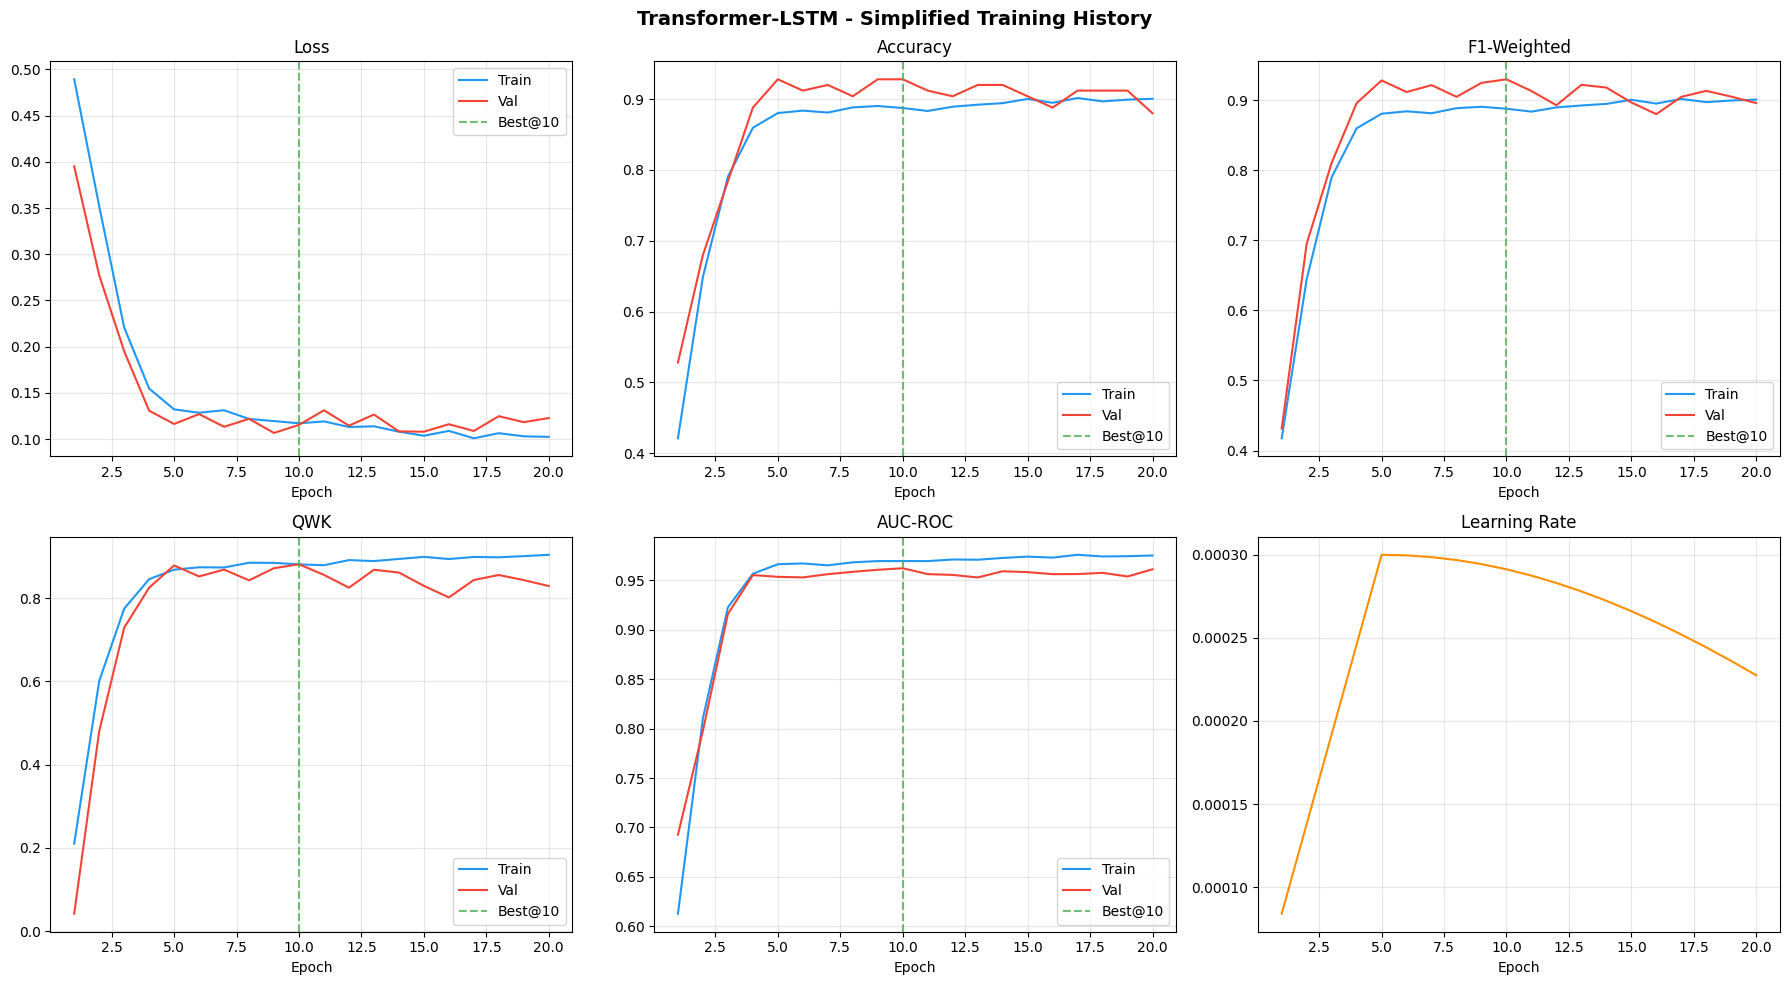

In [ ]:
# ============================================================
# Visualization: Training Curves (Simplified)
# ============================================================

from matplotlib.ticker import MaxNLocator

epochs_x = list(range(1, len(history.get('train_loss', [])) + 1))
if len(epochs_x) == 0:
    raise ValueError('history is empty. Run training cell first.')

best_epoch_plot = int(globals().get('best_epoch', -1))

panels = [
    ('Loss',          'train_loss', 'val_loss'),
    ('Accuracy',      'train_acc', 'val_acc'),
    ('F1-Weighted',   'train_f1_weighted', 'val_f1_weighted'),
    ('QWK',           'train_qwk', 'val_qwk'),
    ('AUC-ROC',       'train_auc', 'val_auc'),
    ('Learning Rate', 'lr', None),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Transformer-LSTM - Simplified Training History', fontsize=14, fontweight='bold')

for ax, (title, tr_key, vl_key) in zip(axes.flat, panels):
    if tr_key is not None and tr_key in history and len(history[tr_key]) > 0:
        tr_color = '#FF8F00' if tr_key == 'lr' else '#2196F3'
        tr_label = 'LR' if tr_key == 'lr' else 'Train'
        ax.plot(epochs_x, history[tr_key], color=tr_color, label=tr_label)

    if vl_key is not None and vl_key in history and len(history[vl_key]) > 0:
        ax.plot(epochs_x, history[vl_key], color='#F44336', label='Val')

    if best_epoch_plot > 0 and best_epoch_plot <= len(epochs_x) and tr_key != 'lr':
        ax.axvline(best_epoch_plot, color='#4CAF50', linestyle='--', alpha=0.8, label=f'Best@{best_epoch_plot}')

    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_xlim(1, len(epochs_x))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(alpha=0.3)
    if tr_key != 'lr':
        ax.legend()

# Remove empty axes
if len(panels) < len(axes.flat):
    for i in range(len(panels), len(axes.flat)):
        fig.delaxes(axes.flat[i])

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'training_history_simplified.png', dpi=150, bbox_inches='tight')
plt.show()

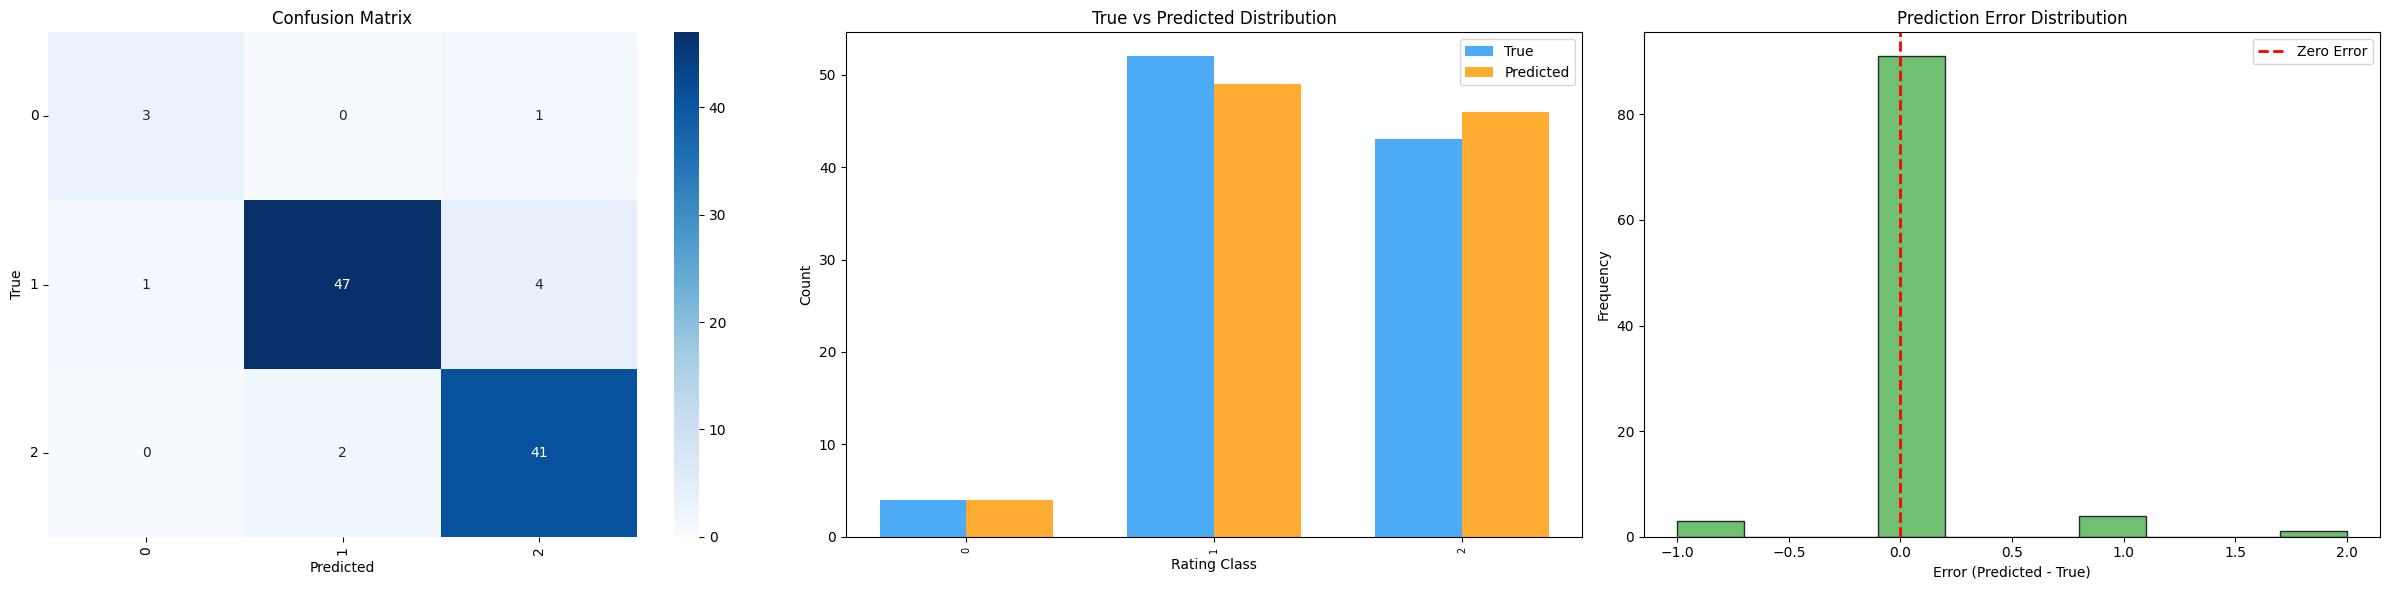

Result plots saved.


In [18]:
# ============================================================
# Visualization: Confusion Matrix + Distributions
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

all_labels = sorted(set(y_true) | set(y_pred))
label_names = [str(i) for i in all_labels]
cm_display = confusion_matrix(y_true, y_pred, labels=all_labels)

if len(all_labels) <= 25:
    sns.heatmap(cm_display, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names, ax=axes[0])
else:
    sns.heatmap(cm_display, cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=90)
axes[0].tick_params(axis='y', rotation=0)

true_counts = pd.Series(y_true).value_counts().sort_index()
pred_counts = pd.Series(y_pred).value_counts().sort_index()
all_idx = sorted(set(true_counts.index) | set(pred_counts.index))
x_pos = np.arange(len(all_idx))
width = 0.35
axes[1].bar(x_pos - width/2, [true_counts.get(i, 0) for i in all_idx],
            width, label='True', alpha=0.8, color='#2196F3')
axes[1].bar(x_pos + width/2, [pred_counts.get(i, 0) for i in all_idx],
            width, label='Predicted', alpha=0.8, color='#FF9800')
axes[1].set_title('True vs Predicted Distribution')
axes[1].set_xlabel('Rating Class')
axes[1].set_ylabel('Count')
axes[1].legend()
if len(all_idx) <= 25:
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(i) for i in all_idx],
                             rotation=90, fontsize=7)

errors = y_pred - y_true
axes[2].hist(errors, bins=max(10, len(set(errors))), color='#4CAF50',
             edgecolor='black', alpha=0.8)
axes[2].set_title('Prediction Error Distribution')
axes[2].set_xlabel('Error (Predicted - True)')
axes[2].set_ylabel('Frequency')
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[2].legend()

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / 'transformer_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Result plots saved.')

In [19]:
# Build ticker-aligned result table for test predictions.
if 'test_seq_tickers' in globals() and len(test_seq_tickers) == len(y_true):
    result_tickers = np.asarray(test_seq_tickers, dtype=object)
else:
    # Safe fallback to avoid length mismatch if upstream cells were not re-run.
    result_tickers = np.array(['UNKNOWN'] * len(y_true), dtype=object)
    print(
        f"Warning: test_seq_tickers length mismatch "
        f"({len(globals().get('test_seq_tickers', []))} vs {len(y_true)}). "
        "Using UNKNOWN tickers."
    )

results = pd.DataFrame({
    'unique_id': result_tickers,
    'y_true_numeric': y_true,
    'y_pred_numeric': y_pred,
})

print('\n=== Sample Predictions ===')
print(f'{"Ticker":<10} {"True (num)":<15} {"Pred (num)":>15} {"Match":>8}')
print('-' * 54)

sample_n = min(30, len(results))
for _, row in results.head(sample_n).iterrows():
    match = 'Y' if row['y_true_numeric'] == row['y_pred_numeric'] else 'N'
    print(f'{row["unique_id"]:<10} '
          f'{int(row["y_true_numeric"]):<15} '
          f'{int(row["y_pred_numeric"]):>15} '
          f'{match:>8}')

print(f'\n=== Summary ===')
print(f'Total predictions: {len(results)}')
print(f'Correct: {(results["y_true_numeric"] == results["y_pred_numeric"]).sum()}')
print(f'Accuracy: {acc:.4f}')
f1_weighted_safe = float(globals().get('f1_weighted', f1_score(results['y_true_numeric'], results['y_pred_numeric'], average='weighted', zero_division=0)))
auc_ovr_safe = float(globals().get('auc_ovr', float('nan')))
print(f'F1 (weighted): {f1_weighted_safe:.4f}')
if not np.isnan(auc_ovr_safe):
    print(f'AUC-ROC (OvR): {auc_ovr_safe:.4f}')
else:
    print('AUC-ROC: N/A')
print(f'\nAll artifacts saved to: {ARTIFACT_DIR.resolve()}')


=== Sample Predictions ===
Ticker     True (num)           Pred (num)    Match
------------------------------------------------------
ADNT       2                             2        Y
ADNT       2                             2        Y
ADNT       2                             2        Y
ADSW       1                             1        Y
ADT        1                             1        Y
AGR        2                             2        Y
AGR        2                             2        Y
ALTR       2                             2        Y
ALTR       2                             2        Y
ALV        2                             2        Y
ALV        2                             2        Y
AMC        1                             1        Y
AMRX       1                             1        Y
CASA       1                             1        Y
CCL        2                             2        Y
CDNS       2                             2        Y
CDNS       2                     

## 11. xAI SHAP Interpretation

Giải thích dự đoán bảng SHAP để phân tích mức độ đóng góp của từng đặc trưng tài chính.


Explaining predicted class probability for class: 1


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/3 [00:00<?, ?it/s]

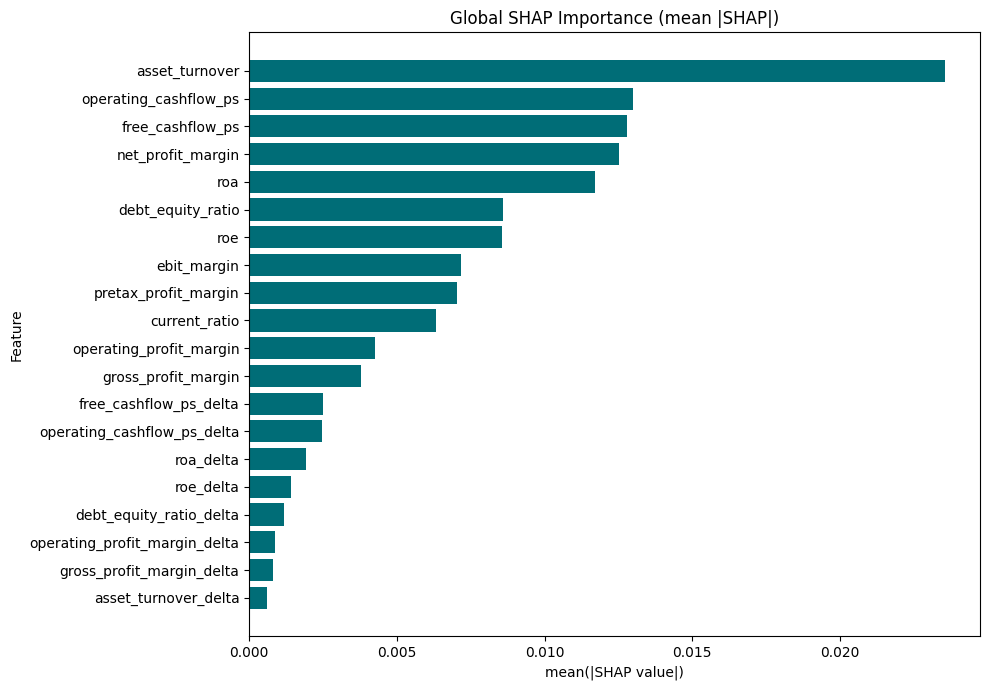

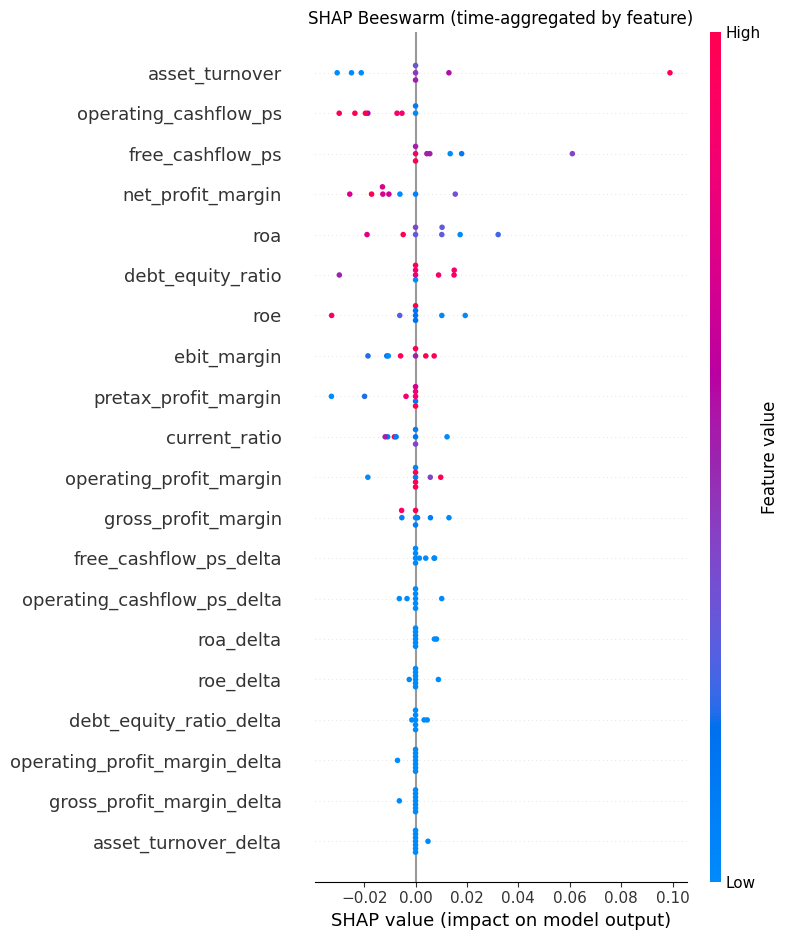

SHAP mode: fast | target: predicted_class
SHAP explained samples: 8
SHAP background windows: 80
SHAP nsamples (KernelExplainer): 120
Top SHAP features (global):
                feature  mean_abs_shap
         asset_turnover       0.023566
  operating_cashflow_ps       0.012983
       free_cashflow_ps       0.012798
      net_profit_margin       0.012527
                    roa       0.011716
      debt_equity_ratio       0.008580
                    roe       0.008545
            ebit_margin       0.007169
   pretax_profit_margin       0.007035
          current_ratio       0.006336
operating_profit_margin       0.004261
    gross_profit_margin       0.003788
Saved: /kaggle/working/credit_rating_artifacts/shap_feature_importance.csv
Saved: /kaggle/working/credit_rating_artifacts/shap_sample_explanations.csv
Saved: /kaggle/working/credit_rating_artifacts/shap_feature_importance.png
Saved: /kaggle/working/credit_rating_artifacts/shap_beeswarm.png


In [20]:
# ============================================================
# SHAP explainability for TLSTM-Fuzzy predictions (synced + robust)
# ============================================================

SHAP_ENABLED = True
SHAP_MODE = 'fast'            # {'fast', 'full'}
SHAP_TARGET = 'predicted_class'  # {'predicted_class', 'all_classes'}
SHAP_RANDOM_STATE = SEED

if SHAP_MODE == 'fast':
    SHAP_MAX_SAMPLES = 8
    SHAP_BACKGROUND_SIZE = 80
    SHAP_NSAMPLES = 120
else:
    SHAP_MAX_SAMPLES = 24
    SHAP_BACKGROUND_SIZE = 180
    SHAP_NSAMPLES = 240


if 'corn_logits_to_proba' not in globals():
    def corn_logits_to_proba(logits, n_classes, enforce_monotonic=True):
        q = torch.sigmoid(logits.float())
        if enforce_monotonic and q.shape[1] > 1:
            q = torch.cummin(q, dim=1)[0]
        eps = 1e-6
        q = q.clamp(eps, 1.0 - eps)
        probs = torch.zeros((q.shape[0], n_classes), device=q.device, dtype=q.dtype)
        probs[:, 0] = 1.0 - q[:, 0]
        if n_classes > 2:
            probs[:, 1:-1] = q[:, :-1] - q[:, 1:]
        probs[:, -1] = q[:, -1]
        probs = probs.clamp_min(eps)
        probs = probs / probs.sum(dim=1, keepdim=True)
        return probs


def _normalize_shap_output(shap_values, n_classes_expected):
    """
    Return (signed_2d, abs_2d) both with shape (N, F).
    Handles SHAP outputs as list or ndarray for binary/multiclass settings.
    """
    if isinstance(shap_values, list):
        if len(shap_values) == 0:
            raise ValueError('Empty SHAP list output.')
        arr = np.stack([np.asarray(v) for v in shap_values], axis=0)  # (K, N, F)
        signed_2d = arr.mean(axis=0)
        abs_2d = np.mean(np.abs(arr), axis=0)
        return np.asarray(signed_2d), np.asarray(abs_2d)

    arr = np.asarray(shap_values)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
        return arr, np.abs(arr)

    if arr.ndim == 2:
        return arr, np.abs(arr)

    if arr.ndim == 3:
        if arr.shape[-1] == n_classes_expected:
            signed_2d = arr.mean(axis=2)
            abs_2d = np.mean(np.abs(arr), axis=2)
            return signed_2d, abs_2d
        if arr.shape[0] == n_classes_expected:
            signed_2d = arr.mean(axis=0)
            abs_2d = np.mean(np.abs(arr), axis=0)
            return signed_2d, abs_2d

        signed_2d = arr.mean(axis=0)
        abs_2d = np.mean(np.abs(arr), axis=0)
        return signed_2d, abs_2d

    raise ValueError(f'Unsupported SHAP output ndim={arr.ndim}')


if SHAP_ENABLED:
    try:
        import shap
    except Exception:
        import subprocess
        import sys
        print('Installing shap package...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '-q'])
        import shap

    rng = np.random.default_rng(SHAP_RANDOM_STATE)

    if len(train_seqs) == 0 or len(test_seqs) == 0:
        raise ValueError('SHAP requires non-empty train_seqs and test_seqs. Re-run previous cells first.')

    train_X_all = np.stack([s[0] for s in train_seqs], axis=0).astype(np.float32)
    test_X_all = np.stack([s[0] for s in test_seqs], axis=0).astype(np.float32)
    test_last_y_all = np.array([s[1] for s in test_seqs], dtype=int)
    test_sector_all = np.array([s[2] for s in test_seqs], dtype=int)
    test_target_all = np.array([s[3] for s in test_seqs], dtype=int)

    has_tickers = ('test_seq_tickers' in globals()) and (len(test_seq_tickers) == len(test_seqs))

    background_size = int(min(SHAP_BACKGROUND_SIZE, len(train_X_all)))
    explain_size = int(min(SHAP_MAX_SAMPLES, len(test_X_all)))

    if background_size <= 0 or explain_size <= 0:
        raise ValueError('Not enough samples to run SHAP. Check train/test split cells.')

    bg_idx = rng.choice(len(train_X_all), size=background_size, replace=False)
    explain_idx = rng.choice(len(test_X_all), size=explain_size, replace=False)

    background_flat = train_X_all[bg_idx].reshape(background_size, -1)
    explain_seqs = test_X_all[explain_idx]  # (N, T, C)
    explain_flat = explain_seqs.reshape(explain_size, -1)
    explain_last_y = test_last_y_all[explain_idx]
    explain_sector = test_sector_all[explain_idx]

    n_features_flat = background_flat.shape[1]
    if n_features_flat != INPUT_SIZE * n_channels:
        raise ValueError(
            f'SHAP flat feature mismatch: got {n_features_flat}, expected {INPUT_SIZE * n_channels}.'
        )

    timestep_labels = [f't-{INPUT_SIZE - 1 - t}' for t in range(INPUT_SIZE)]
    flat_feature_names = [
        f'{step}__{feat}'
        for step in timestep_labels
        for feat in MODEL_FEATURES
    ]

    model.eval()

    def _predict_proba_with_context(x_flat_batch, last_y_value, sector_value):
        x_flat_batch = np.asarray(x_flat_batch, dtype=np.float32)
        if x_flat_batch.ndim == 1:
            x_flat_batch = x_flat_batch.reshape(1, -1)

        x_batch = torch.tensor(
            x_flat_batch.reshape(-1, INPUT_SIZE, n_channels),
            dtype=torch.float32,
            device=device,
        )
        ly_batch = torch.full(
            (x_batch.shape[0],),
            fill_value=int(last_y_value),
            dtype=torch.long,
            device=device,
        )
        sec_batch = torch.full(
            (x_batch.shape[0],),
            fill_value=int(sector_value),
            dtype=torch.long,
            device=device,
        )

        with torch.no_grad():
            logits = model(x_batch, ly_batch, sec_batch)
            if logits.shape[1] == n_classes - 1:
                probs = corn_logits_to_proba(logits, n_classes=n_classes)
            else:
                probs = torch.softmax(logits, dim=1)
        return probs.detach().cpu().numpy()

    # Predict explained samples once using their real contexts.
    with torch.no_grad():
        x_tensor = torch.tensor(explain_seqs, dtype=torch.float32, device=device)
        ly_tensor = torch.tensor(explain_last_y, dtype=torch.long, device=device)
        sec_tensor = torch.tensor(explain_sector, dtype=torch.long, device=device)
        logits_explain = model(x_tensor, ly_tensor, sec_tensor)
        if logits_explain.shape[1] == n_classes - 1:
            probs_explain = corn_logits_to_proba(logits_explain, n_classes=n_classes).cpu().numpy()
        else:
            probs_explain = torch.softmax(logits_explain, dim=1).cpu().numpy()

    y_pred_explain = probs_explain.argmax(axis=1)
    pred_prob_explain = probs_explain[np.arange(explain_size), y_pred_explain]

    if SHAP_TARGET == 'predicted_class':
        target_class = int(np.bincount(y_pred_explain, minlength=n_classes).argmax())
        print(f'Explaining predicted class probability for class: {target_class}')
    else:
        target_class = -1
        print('Explaining all classes and averaging SHAP magnitudes across classes.')

    # Group by context (last_y, sector_id) to keep contextual variables fixed during SHAP.
    context_to_positions = {}
    for sample_pos, (ly_i, sec_i) in enumerate(zip(explain_last_y, explain_sector)):
        key = (int(ly_i), int(sec_i))
        context_to_positions.setdefault(key, []).append(sample_pos)

    rows_feature_imp = []
    rows_detail = []
    agg_signed_feature = []
    agg_feature_values = []

    for (ly_i, sec_i), sample_positions in sorted(context_to_positions.items()):
        local_flat = explain_flat[sample_positions]

        if SHAP_TARGET == 'predicted_class':
            predict_fn = lambda x, ly=ly_i, sec=sec_i: _predict_proba_with_context(x, ly, sec)[:, target_class]
        else:
            predict_fn = lambda x, ly=ly_i, sec=sec_i: _predict_proba_with_context(x, ly, sec)

        explainer = shap.KernelExplainer(
            model=predict_fn,
            data=background_flat,
            link='identity',
        )
        shap_raw = explainer.shap_values(local_flat, nsamples=SHAP_NSAMPLES)
        signed_local, abs_local = _normalize_shap_output(shap_raw, n_classes)

        if signed_local.shape != local_flat.shape:
            raise ValueError(
                f'SHAP shape mismatch for context {(ly_i, sec_i)}: {signed_local.shape} vs {local_flat.shape}'
            )

        for local_i, sample_pos in enumerate(sample_positions):
            global_test_index = int(explain_idx[sample_pos])
            y_true_i = int(test_target_all[global_test_index])
            y_pred_i = int(y_pred_explain[sample_pos])
            pred_prob_i = float(pred_prob_explain[sample_pos])
            ticker_i = str(test_seq_tickers[global_test_index]) if has_tickers else 'UNKNOWN'

            sample_abs = abs_local[local_i]
            sample_signed = signed_local[local_i]

            abs_matrix = sample_abs.reshape(INPUT_SIZE, n_channels)
            signed_matrix = sample_signed.reshape(INPUT_SIZE, n_channels)
            feature_abs = abs_matrix.mean(axis=0)
            feature_signed = signed_matrix.mean(axis=0)

            agg_signed_feature.append(feature_signed)
            agg_feature_values.append(explain_seqs[sample_pos].mean(axis=0))

            for feat, imp in zip(MODEL_FEATURES, feature_abs):
                rows_feature_imp.append({
                    'sample_rank': int(sample_pos + 1),
                    'sample_index': int(global_test_index),
                    'ticker': ticker_i,
                    'y_true': y_true_i,
                    'y_pred': y_pred_i,
                    'pred_prob': pred_prob_i,
                    'target_class_explained': int(target_class),
                    'last_y_context': int(ly_i),
                    'sector_id': int(sec_i),
                    'feature': str(feat),
                    'mean_abs_shap': float(imp),
                })

            topk = int(min(8, len(flat_feature_names)))
            top_pos = np.argsort(-sample_abs)[:topk]
            for p in top_pos:
                rows_detail.append({
                    'sample_rank': int(sample_pos + 1),
                    'sample_index': int(global_test_index),
                    'ticker': ticker_i,
                    'y_true': y_true_i,
                    'y_pred': y_pred_i,
                    'pred_prob': pred_prob_i,
                    'target_class_explained': int(target_class),
                    'feature_flat': flat_feature_names[p],
                    'feature_value': float(local_flat[local_i, p]),
                    'shap_value': float(sample_signed[p]),
                    'abs_shap_value': float(sample_abs[p]),
                    'last_y_context': int(ly_i),
                    'sector_id': int(sec_i),
                })

    shap_feature_df = pd.DataFrame(rows_feature_imp)
    shap_detail_df = pd.DataFrame(rows_detail)

    if len(shap_feature_df) == 0:
        raise ValueError('No SHAP explanations were generated. Check SHAP settings and rerun.')

    shap_global = (
        shap_feature_df.groupby('feature', as_index=False)['mean_abs_shap']
        .mean()
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )

    shap_feature_path = ARTIFACT_DIR / 'shap_feature_importance.csv'
    shap_detail_path = ARTIFACT_DIR / 'shap_sample_explanations.csv'
    shap_bar_path = ARTIFACT_DIR / 'shap_feature_importance.png'
    shap_beeswarm_path = ARTIFACT_DIR / 'shap_beeswarm.png'

    shap_global.to_csv(shap_feature_path, index=False)
    shap_detail_df.to_csv(shap_detail_path, index=False)

    plt.figure(figsize=(10, 7))
    top_plot = shap_global.head(20).iloc[::-1]
    plt.barh(top_plot['feature'], top_plot['mean_abs_shap'], color='#006D77')
    plt.title('Global SHAP Importance (mean |SHAP|)')
    plt.xlabel('mean(|SHAP value|)')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.savefig(shap_bar_path, dpi=180, bbox_inches='tight')
    plt.show()

    if len(agg_signed_feature) > 0:
        agg_signed_feature = np.vstack(agg_signed_feature)
        agg_feature_values = np.vstack(agg_feature_values)

        plt.figure(figsize=(12, 8))
        shap.summary_plot(
            agg_signed_feature,
            agg_feature_values,
            feature_names=MODEL_FEATURES,
            show=False,
        )
        plt.title('SHAP Beeswarm (time-aggregated by feature)')
        plt.tight_layout()
        plt.savefig(shap_beeswarm_path, dpi=180, bbox_inches='tight')
        plt.show()

    print(f'SHAP mode: {SHAP_MODE} | target: {SHAP_TARGET}')
    print(f'SHAP explained samples: {explain_size}')
    print(f'SHAP background windows: {background_size}')
    print(f'SHAP nsamples (KernelExplainer): {SHAP_NSAMPLES}')
    print('Top SHAP features (global):')
    print(shap_global.head(12).to_string(index=False))
    print(f'Saved: {shap_feature_path}')
    print(f'Saved: {shap_detail_path}')
    print(f'Saved: {shap_bar_path}')
    print(f'Saved: {shap_beeswarm_path}')
else:
    print('SHAP is disabled. Set SHAP_ENABLED=True to run explanations.')

## Summary

**Model:** Transformer-LSTM Classifier with Fuzzy feature expansion + Sector Embedding

**Data & Split Guardrails (updated):**
- Enforce ticker disjoint giữa train/val/test.
- Bật synthetic QC trước khi đưa mẫu tổng hợp  vào train.
- Ưu tiên ổn định validation bảng regularization vừa phải  và  early stopping chặt hơn.
